## EDA de los datos preprocesados para la investigación

En este notebook se unirán los conjuntos de datos necesarios para la construcción de modelos eficientes y con una interpretación biológica útil.

In [17]:
import pandas as pd
import seaborn as sns
from sklearn.feature_selection import chi2
from sklearn.ensemble import RandomForestClassifier # Modelos de árboles
import numpy as np
import matplotlib.pyplot as plt

In [18]:
# 100 genes hub extraídos
top100_genes = [
    "CD4", "CD8A", "CD247", "CD48", "CD28", "CD2", "LCK", "LCP2", "SPN", "PTPRC",
    "ITK", "HLA-DRA", "SH2D1A", "HLA-DPB1", "HLA-DOA", "CD3D", "CD40", "CTLA4", "RASSF5", "ITGAL",
    "FBN1", "COL3A1", "PLIN1", "BTK", "CD3G", "CD5", "LY9", "SLAMF6", "CD3E", "TRAT1",
    "CD226", "GZMK", "CD27", "CD86", "GZMA", "TNFRSF9", "KLRK1", "KLRD1", "TNFRSF8", "ICOS",
    "FYN", "FOXP3", "C1QB", "C1QA", "C1QC", "CD79A", "IL10", "CCL4", "ITGA4", "ITGAM",
    "CXCL12", "CCL19", "IDO1", "CCL21", "LUM", "COL5A2", "ADH1A", "ADH1B", "ADH1C", "ADIPOQ",
    "CIDEA", "CIDEC", "KRT16", "WIPF1", "EVI2B", "HCLS1", "IL16", "PLEK", "PIK3R5", "SELPLG",
    "EVI2A", "CCR5", "CARD11", "HLA-DMB", "PRKCB", "PDCD1LG2", "APBB1IP", "FERMT3", "CD6", "PIK3CD",
    "CD40LG", "ITGB2", "CXCR3", "EOMES", "TIGIT", "CXCR6", "KCNA3", "CYBB", "PRF1", "NCF4",
    "KLRB1", "KCNAB2", "HLA-E", "HLA-DMA", "ITGAX", "CTSS", "TNFSF8", "SPI1", "IRF4", "CD74"
]

In [19]:
path_scna = "data/Human__TCGA_BRCA__BI__SCNA__SNP_6.0__01_28_2016__BI__Gene__Firehose_GISTIC2.cct"
path_mutation = "data/Human__TCGA_BRCA__WUSM__Mutation__GAIIx__01_28_2016__BI__Gene__Firehose_MutSig2CV.cbt"

In [20]:
muta = pd.read_csv(path_mutation, sep='\t', index_col=0) # dataset sobre mutaciones de genes
scna_gen = pd.read_csv(path_scna, sep='\t', index_col=0) # dataset de cambios en el número de copias de los genes

In [21]:
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

Dimensión datos mutaciones: (7966, 975)
Dimensión datos scna: (24776, 1080)


In [22]:
# ver cuantos coinciden del top 100
scna_gen = scna_gen.loc[scna_gen.index.isin(top100_genes)]
muta = muta.loc[muta.index.isin(top100_genes)]

print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

Dimensión datos mutaciones: (39, 975)
Dimensión datos scna: (94, 1080)


In [23]:
scna_gen = scna_gen.T
scna_gen.head()

attrib_name,KCNAB2,TNFRSF9,PIK3CD,TNFRSF8,C1QA,C1QC,C1QB,LCK,KCNA3,CD2,CTSS,SLAMF6,CD48,LY9,CD247,PTPRC,RASSF5,IL10,PLEK,CD8A,WIPF1,ITGA4,COL3A1,COL5A2,CD28,CTLA4,ICOS,CIDEC,EOMES,CXCR6,CCR5,TRAT1,TIGIT,HCLS1,CD86,ADIPOQ,ADH1A,ADH1B,ADH1C,GZMK,...,PRF1,SPI1,CD6,CD5,FERMT3,CD3E,CD3D,CD3G,CD27,CD4,KLRB1,KLRD1,KLRK1,LUM,SELPLG,FBN1,IL16,PLIN1,PRKCB,SPN,ITGAL,ITGAM,ITGAX,PIK3R5,EVI2B,EVI2A,CCL4,KRT16,CIDEA,CD226,CD79A,CD40,ITGB2,NCF4,CYBB,FOXP3,CXCR3,BTK,SH2D1A,CD40LG
TCGA.3C.AAAU,0.069,0.069,0.069,0.069,0.069,0.069,0.069,0.069,0.216,0.216,3.657,0.167,0.167,0.167,-0.454,0.203,0.203,0.203,-0.421,-0.421,-0.399,-0.399,-0.399,-0.399,-0.399,-0.399,-0.399,-0.458,-0.458,-0.458,-0.458,0.259,0.259,0.259,0.259,0.259,-0.373,-0.373,-0.373,0.248,...,-0.468,0.184,2.437,2.437,-0.600,-0.465,-0.465,-0.465,0.186,0.186,0.186,0.186,0.186,-0.470,-0.470,0.149,0.118,0.118,0.053,0.053,0.053,0.053,0.053,-0.567,0.078,0.078,0.078,0.078,0.202,0.215,0.000,0.017,0.663,-0.596,0.274,0.274,-0.395,-0.395,-0.395,-0.395
TCGA.3C.AALI,-1.008,-0.518,-0.518,-0.518,-0.518,-0.518,-0.518,-0.518,-0.448,-0.448,0.387,0.387,0.387,0.387,0.387,0.387,0.397,0.397,0.410,0.410,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.475,0.444,-0.476,-0.476,0.476,0.476,0.476,0.476,0.476,-0.436,-0.436,-0.436,0.482,...,-0.461,0.007,0.007,0.007,0.007,-0.973,-0.973,-0.973,-0.007,-0.007,-0.007,-0.007,-0.007,0.000,0.000,0.028,-0.016,-0.016,0.032,0.032,0.032,0.032,0.032,-0.525,-0.538,-0.538,2.743,-0.534,-0.454,-0.939,0.096,0.783,-0.538,-0.533,0.879,0.879,-0.469,-0.469,-0.469,-0.469
TCGA.3C.AALJ,-0.330,-0.330,-0.330,-0.330,-0.324,-0.324,-0.324,-0.324,0.083,0.083,0.083,0.421,0.421,0.421,0.421,0.421,0.435,0.435,0.374,0.374,-0.381,-0.381,-0.381,-0.381,-0.381,-0.381,-0.381,0.000,0.000,0.000,0.000,0.000,0.000,-0.138,-0.138,-0.145,-0.317,-0.317,-0.317,0.025,...,0.735,0.015,0.015,0.015,-0.321,-0.321,-0.321,-0.321,0.388,0.388,0.025,0.025,0.025,0.373,0.371,-0.327,-0.327,-0.327,0.008,0.008,0.008,0.008,0.008,-0.694,-0.693,-0.693,1.406,1.090,0.105,0.171,0.005,-0.705,-0.329,-0.695,-0.063,-0.063,-0.063,-0.063,-0.063,-0.063
TCGA.3C.AALK,-0.023,-0.023,-0.023,-0.023,-0.023,-0.023,-0.023,-0.023,-0.023,-0.023,0.589,0.619,0.619,0.619,0.619,0.617,0.617,0.617,-0.003,-0.007,-0.007,-0.007,-0.007,-0.007,-0.007,-0.007,-0.007,-0.016,-0.016,-0.058,-0.058,-0.058,-0.058,-0.058,-0.058,-0.058,-0.033,-0.033,-0.033,0.023,...,0.014,0.018,0.018,0.018,0.023,-0.172,-0.172,-0.172,-0.002,-0.002,-0.002,-0.002,-0.002,0.000,0.000,0.025,0.025,0.025,0.025,0.025,0.025,0.025,0.025,-0.644,-0.612,-0.612,0.685,-0.641,-0.004,-0.012,-0.012,0.032,-0.045,0.020,0.011,0.011,0.008,0.008,0.008,0.008
TCGA.4H.AAAK,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.303,-0.303,-0.303,-0.301,0.031,0.031,0.031,0.031,0.031,0.005,0.005,0.009,0.009,-0.001,-0.001,-0.001,-0.001,-0.003,-0.004,-0.004,-0.004,0.034,...,0.009,0.002,0.002,0.002,0.002,-0.652,-0.652,-0.652,-0.344,-0.344,-0.344,-0.344,-0.344,-0.015,-0.015,-0.001,0.105,0.105,0.027,0.027,0.027,0.027,0.027,-0.669,0.289,0.289,0.289,0.289,0.013,0.013,0.295,0.029,-0.014,-0.028,-0.020,-0.020,-0.020,-0.020,-0.020,-0.020


In [24]:
scna_gen.dtypes

attrib_name
KCNAB2     float64
TNFRSF9    float64
PIK3CD     float64
TNFRSF8    float64
C1QA       float64
            ...   
FOXP3      float64
CXCR3      float64
BTK        float64
SH2D1A     float64
CD40LG     float64
Length: 94, dtype: object

In [25]:
scna_gen.describe()

attrib_name,KCNAB2,TNFRSF9,PIK3CD,TNFRSF8,C1QA,C1QC,C1QB,LCK,KCNA3,CD2,CTSS,SLAMF6,CD48,LY9,CD247,PTPRC,RASSF5,IL10,PLEK,CD8A,WIPF1,ITGA4,COL3A1,COL5A2,CD28,CTLA4,ICOS,CIDEC,EOMES,CXCR6,CCR5,TRAT1,TIGIT,HCLS1,CD86,ADIPOQ,ADH1A,ADH1B,ADH1C,GZMK,...,PRF1,SPI1,CD6,CD5,FERMT3,CD3E,CD3D,CD3G,CD27,CD4,KLRB1,KLRD1,KLRK1,LUM,SELPLG,FBN1,IL16,PLIN1,PRKCB,SPN,ITGAL,ITGAM,ITGAX,PIK3R5,EVI2B,EVI2A,CCL4,KRT16,CIDEA,CD226,CD79A,CD40,ITGB2,NCF4,CYBB,FOXP3,CXCR3,BTK,SH2D1A,CD40LG
count,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,...,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000,1080.000000
mean,-0.147697,-0.150406,-0.153656,-0.157820,-0.159429,-0.159429,-0.159461,-0.086812,-0.053232,-0.006197,0.616717,0.590684,0.604578,0.606268,0.566087,0.577087,0.610653,0.611544,0.016382,0.011526,-0.043498,-0.032137,-0.026295,-0.025686,-0.036798,-0.039041,-0.039448,0.036492,-0.030149,-0.109169,-0.110309,0.064159,0.070083,0.051955,0.052862,0.137774,-0.074731,-0.074076,-0.072624,-0.021566,...,-0.019384,0.011102,-0.000002,0.007570,-0.029398,-0.227471,-0.230589,-0.230589,0.084180,0.085240,0.061960,0.068673,0.068173,0.035383,-0.002519,-0.098782,-0.016346,0.009348,0.288103,0.297864,0.301381,0.291744,0.293425,-0.275048,-0.019007,-0.020099,0.001206,-0.008689,-0.031696,-0.067564,0.036795,0.251181,0.053590,-0.169368,-0.006236,0.017829,-0.009128,-0.022713,-0.003926,0.010493
std,0.292986,0.290509,0.292027,0.288639,0.278078,0.278078,0.278171,0.294108,0.304635,0.371226,0.631314,0.550243,0.593119,0.577528,0.532172,0.533981,0.585213,0.586891,0.236184,0.229316,0.242394,0.234073,0.236845,0.237576,0.230507,0.227815,0.228039,0.325174,0.265109,0.274621,0.274996,0.285505,0.308739,0.278882,0.286140,0.362877,0.262334,0.263279,0.265394,0.354404,...,0.312833,0.301836,0.354816,0.373672,0.348167,0.366097,0.358900,0.358900,0.420988,0.423845,0.404344,0.436785,0.434980,0.351304,0.269184,0.322310,0.367354,0.424311,0.453647,0.463491,0.479043,0.473893,0.482911,0.341265,0.448476,0.447735,0.511785,0.456213,0.348220,0.367390,0.301153,0.463798,0.342625,0.345697,0.188838,0.242418,0.174882,0.177854,0.184478,0.209664
min,-1.293000,-1.293000,-1.293000,-1.293000,-1.241000,-1.241000,-1.241000,-0.903000,-0.922000,-1.293000,-0.436000,-0.797000,-0.848000,-0.797000,-0.744000,-0.750000,-0.820000,-0.820000,-1.177000,-0.873000,-1.165000,-0.860000,-0.860000,-0.860000,-0.910000,-0.910000,-0.910000,-0.972000,-0.906000,-0.947000,-0.947000,-0.910000,-0.910000,-0.910000,-0.910000,-0.822000,-0.896000,-0.896000,-0.896000,-1.054000,...,-0.923000,-0.981000,-1.086000,-1.086000,-1.161000,-1.203000,-1.203000,-1.203000,-1.029000,-1.029000,-0.967000,-0.951000,-0.951000,-0.941000,-0.875000,-0.964000,-1.155000,-1.213000,-0.869000,-0.799000,-0.799000,-0.799000,-0.799000,-1.293000,-1.293000,-1.293000,-1.069000,-0.917000,-1.129000,-1.180000,-0.825000,-0.965000,-1.025000,-1.056000,-0.768000,-0.867000,-0.890000,-1.293000,-0.901000,-0.750000
25%,-0.348000,-0.348500,-0.350000,-0.356000,-0.350750,-0.350750,-0.350750,-0.244250,-0.191250,-0.105500,0.068250,0.080750,0.081000,0.086750,0.078750,0.098750,0.104750,0.104750,-0.015000,-0.016000,-0.062000,-0.053500,-0.052250,-0.052250,-0.064250,-0.066

In [26]:
muta = muta.T
muta.head()

attrib_name,ADH1C,APBB1IP,BTK,CARD11,CD2,CD3E,CD3G,CD4,CD5,CD86,CD8A,COL3A1,COL5A2,CXCR3,EOMES,FBN1,GZMA,HLA-DMB,ICOS,ITGA4,ITGAL,ITGAM,ITGAX,ITGB2,ITK,KCNA3,KCNAB2,LY9,NCF4,PIK3CD,PIK3R5,PLIN1,PRKCB,PTPRC,RASSF5,SPI1,TIGIT,TNFRSF8,TRAT1
TCGA.A8.A09Z,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1
TCGA.AC.A2FB,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TCGA.BH.A0HP,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
TCGA.D8.A1J8,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
TCGA.A8.A0A6,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [27]:
muta.dtypes

attrib_name
ADH1C      int64
APBB1IP    int64
BTK        int64
CARD11     int64
CD2        int64
CD3E       int64
CD3G       int64
CD4        int64
CD5        int64
CD86       int64
CD8A       int64
COL3A1     int64
COL5A2     int64
CXCR3      int64
EOMES      int64
FBN1       int64
GZMA       int64
HLA-DMB    int64
ICOS       int64
ITGA4      int64
ITGAL      int64
ITGAM      int64
ITGAX      int64
ITGB2      int64
ITK        int64
KCNA3      int64
KCNAB2     int64
LY9        int64
NCF4       int64
PIK3CD     int64
PIK3R5     int64
PLIN1      int64
PRKCB      int64
PTPRC      int64
RASSF5     int64
SPI1       int64
TIGIT      int64
TNFRSF8    int64
TRAT1      int64
dtype: object

In [28]:
data = pd.read_csv('data/data_with_survival3yr_ht_brca.csv', index_col=0)
data.head()

,CD4,CD8A,CD247,CD48,CD28,CD2,LCK,LCP2,SPN,PTPRC,ITK,HLA-DRA,SH2D1A,HLA-DPB1,HLA-DOA,CD3D,CD40,CTLA4,RASSF5,ITGAL,FBN1,COL3A1,PLIN1,BTK,CD3G,CD5,LY9,SLAMF6,CD3E,TRAT1,CD226,GZMK,CD27,CD86,GZMA,TNFRSF9,KLRK1,KLRD1,TNFRSF8,ICOS,...,EVI2A,CCR5,CARD11,HLA-DMB,PRKCB,PDCD1LG2,APBB1IP,FERMT3,CD6,PIK3CD,CD40LG,ITGB2,CXCR3,EOMES,TIGIT,CXCR6,KCNA3,CYBB,PRF1,NCF4,KLRB1,KCNAB2,HLA-E,HLA-DMA,ITGAX,CTSS,TNFSF8,SPI1,IRF4,CD74,overallsurvival,status,survival_3yr,histological_type_infiltratingductalcarcinoma,histological_type_infiltratinglobularcarcinoma,histological_type_medullarycarcinoma,histological_type_metaplasticcarcinoma,histological_type_mixedhistology(pleasespecify),histological_type_mucinouscarcinoma,"histological_type_other,specify"
TCGA.3C.AAAU,8.8185,4.2936,4.2155,6.2175,4.1885,4.9045,5.2034,7.3178,6.5071,7.8029,3.7450,11.7832,2.0363,10.3610,7.7645,3.8862,8.1652,1.7709,7.2703,6.5449,10.9067,14.9476,5.2822,6.3144,2.8488,4.8191,3.6292,4.1043,5.5812,2.3606,3.1014,3.7074,5.6444,6.2635,3.4588,0.4273,4.8169,1.4454,3.9519,1.2501,...,5.8970,5.1343,6.2955,8.5846,5.0316,3.6688,7.1633,7.5344,5.8547,7.0849,3.1014,9.5592,4.2155,1.7709,3.1582,3.9519,3.1014,8.1927,4.0750,6.1350,3.1014,8.3864,11.2440,8.3288,8.0119,8.7985,3.6688,7.7133,5.5915,13.2504,4047.0,False,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
TCGA.3C.AALI,10.4047,9.4247,7.6203,8.4849,6.1527,9.1515,8.4539,8.9897,8.0395,10.0082,7.4241,13.6705,6.6116,12.0807,9.5639,7.7278,8.3543,6.0734,9.0322,9.8412,12.2492,16.1326,8.4336,7.0088,5.4401,8.1975,5.7334,6.8882,8.9943,5.3274,4.8982,7.8953,8.0009,7.9971,7.4378,5.0715,6.3387,5.8193,5.4035,5.6263,...,7.4195,8.4650,7.7965,9.9379,7.3395,6.6196,8.3851,9.2604,9.3169,8.3326,5.0241,11.0109,7.7929,5.6263,6.7346,6.9079,4.9243,9.6128,7.5921,7.6789,5.1399,8.2931,12.9247,10.0613,9.1180,10.7581,4.9750,9.3388,6.8816,15.3541,4005.0,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA.3C.AALJ,10.5608,8.9436,7.4216,8.4212,6.4300,8.8784,8.0088,8.8390,7.9571,10.0072,8.3707,13.6927,6.1273,12.1887,9.0536,7.9519,7.9884,5.8152,9.4153,9.0972,12.2701,16.0887,9.7011,6.9577,5.7437,7.8364,5.2197,7.8017,9.1557,4.6712,3.8678,8.4212,7.7976,7.5940,7.8591,4.5647,6.2003,3.1953,4.7217,5.1104,...,7.5246,7.6794,7.5597,9.6853,7.1356,5.9900,8.4883,9.2382,8.6403,8.5697,5.8832,10.8976,7.5246,6.2866,6.9041,6.6014,4.1879,8.8784,7.3106,7.9466,6.1824,8.7169,12.7193,9.8216,8.4956,10.3842,5.6686,9.1942,6.4451,15.2534,1474.0,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA.3C.AALK,10.0961,7.2868,6.8165,7.8623,5.5266,8.0631,7.3393,8.4140,7.7251,9.2380,6.2536,13.4352,5.0199,11.7404,9.0793,6.6950,7.7280,5.5266,8.7525,8.7649,13.0420,17.5818,6.3074,7.0640,4.6437,6.9719,5.4467,5.9692,8.0406,3.7003,4.0275,6.5686,7.8540,7.4007,6.2220,5.3476,5.4051,4.5190,4.7584,3.7893,...,7.7805,7.2830,7.0048,9.5118,5.9500,5.5005,7.7392,8.5235,7.1590,8.2687,4.4928,10.3662,6.4022,3.8732,6.4977,6.2299,4.7584,8.9465,5.8808,7.7913,5.0740,7.9152,12.3689,9.9607,8.1830,9.7570,4.5190,9.0184,6.6302,15.2326,1448.0,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA.4H.AAAK,10.2438,6.6942,5.8264,7.1824,6.8191,7.5790,6.8136,8.3322,7.2566,9.3768,5.6784,13.4727,4.6340,11.8580,9.1076,6.2132,7.3648,5.2487,8.5944,8.0765,13.5766,17.8717,6.2378,7.5066,3.8270,6.3773,4.5315,5.6420,7.4161,2.8842,3.9512,6.3323,6.7528,7.7542,6.1367,4.1372,5.0219,3.6426,4.4213,4.2382,...,7.9679,6.9930,7.2962,9.7334,6.1541,5.8795,8.0208,8.9674,7.0311,8.4492,4.4496,10.8461,5.7600,4.1018,5.8264,4.8622,3.7377,9.7549,5.4587,7.1951,4.6091,8.0582,12.4686,9.6677,8.7191,10.0367,5.2161,8.9073,5.1657,14.9584,348.0,False,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


Es necesario juntar los tres dataset en función de los genes que se encuentren en todos, esto reduce el conjunto final, pero permite usar algo representativo en función de los datos existentes. 

Mientras las mutaciones se representan como 0 o 1 si no ha mutado o si sí lo ha hecho, los scna se definen como valores flotantes negativos o positivos, donde un valor positivo es una amplificación y uno negativo una deleción.

In [29]:
# Renombrar columnas para indicar origen
scna_renamed = scna_gen.add_suffix('_scna')
data_renamed = data.add_suffix('_expression')
muta_renamed = muta.add_suffix('_muta')

# Encontrar genes comunes (quitando sufijos)
genes_data = set([col.replace('_expression', '') for col in data_renamed.columns])
genes_scna = set([col.replace('_scna', '') for col in scna_renamed.columns])
genes_muta = set([col.replace('_muta', '') for col in muta_renamed.columns])

common_genes = genes_data & genes_scna & genes_muta

# Filtrar columnas de genes comunes
cols_data_common = [gene + '_expression' for gene in common_genes]
cols_scna_common = [gene + '_scna' for gene in common_genes]
cols_muta_common = [gene + '_muta' for gene in common_genes]

# Filtrar cada DataFrame
data_filtered = data_renamed[cols_data_common]
scna_filtered = scna_renamed[cols_scna_common]
muta_filtered = muta_renamed[cols_muta_common]

# Unir los datos por índice (muestras)
merged_data = data_filtered.join(scna_filtered, how='inner')
merged_data = merged_data.join(muta_filtered, how='inner')

# Mantener columnas adicionales originales
extra_cols = [col for col in data.columns if col.startswith('histological') or
              col in ['status', 'survival_3yr', 'overallsurvival']]
# Extraer sin sufijo porque ya existen en "data"
extra_data = data[extra_cols]
merged_data = merged_data.join(extra_data, how='inner')

# Ordenar columnas: cada gen con expresión, SCNA, muta lado a lado
ordered_cols = []
for gene in sorted(common_genes):
    ordered_cols += [gene + '_expression', gene + '_scna', gene + '_muta']
ordered_cols += extra_cols

merged_data = merged_data[ordered_cols]

# Ver primeras filas
merged_data.head()

,ADH1C_expression,ADH1C_scna,ADH1C_muta,APBB1IP_expression,APBB1IP_scna,APBB1IP_muta,BTK_expression,BTK_scna,BTK_muta,CARD11_expression,CARD11_scna,CARD11_muta,CD2_expression,CD2_scna,CD2_muta,CD3E_expression,CD3E_scna,CD3E_muta,CD3G_expression,CD3G_scna,CD3G_muta,CD4_expression,CD4_scna,CD4_muta,CD5_expression,CD5_scna,CD5_muta,CD86_expression,CD86_scna,CD86_muta,CD8A_expression,CD8A_scna,CD8A_muta,COL3A1_expression,COL3A1_scna,COL3A1_muta,COL5A2_expression,COL5A2_scna,COL5A2_muta,CXCR3_expression,...,PIK3CD_expression,PIK3CD_scna,PIK3CD_muta,PIK3R5_expression,PIK3R5_scna,PIK3R5_muta,PLIN1_expression,PLIN1_scna,PLIN1_muta,PRKCB_expression,PRKCB_scna,PRKCB_muta,PTPRC_expression,PTPRC_scna,PTPRC_muta,RASSF5_expression,RASSF5_scna,RASSF5_muta,SPI1_expression,SPI1_scna,SPI1_muta,TIGIT_expression,TIGIT_scna,TIGIT_muta,TNFRSF8_expression,TNFRSF8_scna,TNFRSF8_muta,TRAT1_expression,TRAT1_scna,TRAT1_muta,overallsurvival,status,survival_3yr,histological_type_infiltratingductalcarcinoma,histological_type_infiltratinglobularcarcinoma,histological_type_medullarycarcinoma,histological_type_metaplasticcarcinoma,histological_type_mixedhistology(pleasespecify),histological_type_mucinouscarcinoma,"histological_type_other,specify"
TCGA.A1.A0SB,4.0676,-0.001,0,6.1278,-0.001,0,4.6367,0.000,0,5.2457,0.006,0,3.6162,0.002,0,3.9036,-0.001,0,1.7015,-0.001,0,7.7237,-0.002,0,2.6794,0.001,0,5.1755,0.000,0,4.8988,-0.001,0,15.3032,0.000,0,12.0718,0.000,0,1.7015,...,7.6185,0.002,0,5.1391,-0.002,0,6.6389,0.002,0,4.0283,0.002,0,7.2125,0.002,0,9.1819,0.002,0,6.5446,0.001,0,0.5366,0.000,0,1.8887,0.002,0,1.2336,0.000,0,259.0,False,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
TCGA.A1.A0SD,2.4062,-0.007,0,7.7529,0.103,0,6.8136,-0.060,0,6.3815,0.000,0,7.4890,-0.433,0,7.4649,-0.542,0,4.5745,-0.542,0,9.7639,0.000,0,6.3350,-0.521,0,7.6569,-0.011,0,6.4650,-0.011,0,16.1356,-0.010,0,13.5476,-0.010,0,5.4268,...,8.1133,-0.521,0,6.9278,-0.515,0,9.9020,0.525,0,6.3986,0.040,0,9.4615,0.088,0,8.4126,0.088,0,8.1888,0.009,0,5.7442,-0.011,0,3.7269,-0.521,0,4.1327,-0.011,0,437.0,False,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA.A1.A0SE,4.1789,-0.010,0,6.5865,0.813,0,6.6013,-0.008,0,6.0334,0.000,0,7.5765,-0.047,0,7.7975,-0.481,0,4.9670,-0.481,0,9.1713,0.006,0,6.0189,-0.399,0,6.3683,0.012,0,7.9123,0.003,0,17.4795,0.003,0,14.1685,0.003,0,5.2674,...,8.0223,-0.060,0,6.2297,-0.513,0,4.2304,-0.007,0,6.4895,0.461,0,8.8426,0.872,0,8.4176,0.872,0,7.3125,0.003,0,4.8066,0.012,0,4.0415,-0.060,0,3.0426,0.012,0,1321.0,False,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0
TCGA.A1.A0SF,5.3368,0.020,0,8.1893,0.347,0,6.9586,0.065,0,7.2255,0.351,0,9.1984,0.705,0,9.5967,-0.007,0,6.3942,-0.007,0,10.3901,0.396,0,7.9123,-0.007,0,7.1095,-0.002,0,9.4085,-0.003,0,16.5342,-0.003,0,12.7459,-0.003,0,7.0823,...,8.0210,-0.015,0,7.3329,-0.385,0,9.4830,2.642,0,7.8332,0.391,0,10.1479,0.686,0,8.7491,0.686,0,8.0186,-0.007,0,7.2005,-0.002,0,3.4959,-0.015,0,5.4821,-0.002,0,1463.0,False,1,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TCGA.A1.A0SG,1.8156,-0.012,0,8.1031,0.000,0,7.8543,0.010,0,7.6702,0.004,0,6.8515,0.008,0,7.3803,-0.009,0,4.4751,-0.009,0,9.5860,0.012,0,5.8550,-0.009,0,7.6130,-0.007,0,6.8958,0.000,0,16.6147,0.000,0,13.6455,0.000,0,5.3813,...,8.4506,0.008,0,7.3614,0.023,0,7.6156,0.004,0,8.2227,1.205,0,9.7945,0.008,0,8.5592,0.008,0,8.4535,-0.009,0,5.1227,-0.007,0,3.0976,0.008,0,3.8032,-0.007,0,434.0,False,0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [30]:
# Mover la columna 'survival_3yr' al final del DataFrame ya que es el target
cols = [col for col in merged_data.columns if col != 'survival_3yr'] + ['survival_3yr']
merged_data = merged_data[cols]

In [31]:
merged_data = merged_data.drop(['overallsurvival'], axis=1)

In [32]:
merged_data.head()

,ADH1C_expression,ADH1C_scna,ADH1C_muta,APBB1IP_expression,APBB1IP_scna,APBB1IP_muta,BTK_expression,BTK_scna,BTK_muta,CARD11_expression,CARD11_scna,CARD11_muta,CD2_expression,CD2_scna,CD2_muta,CD3E_expression,CD3E_scna,CD3E_muta,CD3G_expression,CD3G_scna,CD3G_muta,CD4_expression,CD4_scna,CD4_muta,CD5_expression,CD5_scna,CD5_muta,CD86_expression,CD86_scna,CD86_muta,CD8A_expression,CD8A_scna,CD8A_muta,COL3A1_expression,COL3A1_scna,COL3A1_muta,COL5A2_expression,COL5A2_scna,COL5A2_muta,CXCR3_expression,...,NCF4_muta,PIK3CD_expression,PIK3CD_scna,PIK3CD_muta,PIK3R5_expression,PIK3R5_scna,PIK3R5_muta,PLIN1_expression,PLIN1_scna,PLIN1_muta,PRKCB_expression,PRKCB_scna,PRKCB_muta,PTPRC_expression,PTPRC_scna,PTPRC_muta,RASSF5_expression,RASSF5_scna,RASSF5_muta,SPI1_expression,SPI1_scna,SPI1_muta,TIGIT_expression,TIGIT_scna,TIGIT_muta,TNFRSF8_expression,TNFRSF8_scna,TNFRSF8_muta,TRAT1_expression,TRAT1_scna,TRAT1_muta,status,histological_type_infiltratingductalcarcinoma,histological_type_infiltratinglobularcarcinoma,histological_type_medullarycarcinoma,histological_type_metaplasticcarcinoma,histological_type_mixedhistology(pleasespecify),histological_type_mucinouscarcinoma,"histological_type_other,specify",survival_3yr
TCGA.A1.A0SB,4.0676,-0.001,0,6.1278,-0.001,0,4.6367,0.000,0,5.2457,0.006,0,3.6162,0.002,0,3.9036,-0.001,0,1.7015,-0.001,0,7.7237,-0.002,0,2.6794,0.001,0,5.1755,0.000,0,4.8988,-0.001,0,15.3032,0.000,0,12.0718,0.000,0,1.7015,...,0,7.6185,0.002,0,5.1391,-0.002,0,6.6389,0.002,0,4.0283,0.002,0,7.2125,0.002,0,9.1819,0.002,0,6.5446,0.001,0,0.5366,0.000,0,1.8887,0.002,0,1.2336,0.000,0,False,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
TCGA.A1.A0SD,2.4062,-0.007,0,7.7529,0.103,0,6.8136,-0.060,0,6.3815,0.000,0,7.4890,-0.433,0,7.4649,-0.542,0,4.5745,-0.542,0,9.7639,0.000,0,6.3350,-0.521,0,7.6569,-0.011,0,6.4650,-0.011,0,16.1356,-0.010,0,13.5476,-0.010,0,5.4268,...,0,8.1133,-0.521,0,6.9278,-0.515,0,9.9020,0.525,0,6.3986,0.040,0,9.4615,0.088,0,8.4126,0.088,0,8.1888,0.009,0,5.7442,-0.011,0,3.7269,-0.521,0,4.1327,-0.011,0,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
TCGA.A1.A0SE,4.1789,-0.010,0,6.5865,0.813,0,6.6013,-0.008,0,6.0334,0.000,0,7.5765,-0.047,0,7.7975,-0.481,0,4.9670,-0.481,0,9.1713,0.006,0,6.0189,-0.399,0,6.3683,0.012,0,7.9123,0.003,0,17.4795,0.003,0,14.1685,0.003,0,5.2674,...,0,8.0223,-0.060,0,6.2297,-0.513,0,4.2304,-0.007,0,6.4895,0.461,0,8.8426,0.872,0,8.4176,0.872,0,7.3125,0.003,0,4.8066,0.012,0,4.0415,-0.060,0,3.0426,0.012,0,False,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
TCGA.A1.A0SF,5.3368,0.020,0,8.1893,0.347,0,6.9586,0.065,0,7.2255,0.351,0,9.1984,0.705,0,9.5967,-0.007,0,6.3942,-0.007,0,10.3901,0.396,0,7.9123,-0.007,0,7.1095,-0.002,0,9.4085,-0.003,0,16.5342,-0.003,0,12.7459,-0.003,0,7.0823,...,0,8.0210,-0.015,0,7.3329,-0.385,0,9.4830,2.642,0,7.8332,0.391,0,10.1479,0.686,0,8.7491,0.686,0,8.0186,-0.007,0,7.2005,-0.002,0,3.4959,-0.015,0,5.4821,-0.002,0,False,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1
TCGA.A1.A0SG,1.8156,-0.012,0,8.1031,0.000,0,7.8543,0.010,0,7.6702,0.004,0,6.8515,0.008,0,7.3803,-0.009,0,4.4751,-0.009,0,9.5860,0.012,0,5.8550,-0.009,0,7.6130,-0.007,0,6.8958,0.000,0,16.6147,0.000,0,13.6455,0.000,0,5.3813,...,0,8.4506,0.008,0,7.3614,0.023,0,7.6156,0.004,0,8.2227,1.205,0,9.7945,0.008,0,8.5592,0.008,0,8.4535,-0.009,0,5.1227,-0.007,0,3.0976,0.008,0,3.8032,-0.007,0,False,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0


In [33]:
# General info
print("Resumen de tipos de datos y valores no nulos:")
merged_data.info()

print("\nConteo de valores para la variable objetivo:")
merged_data['survival_3yr'].value_counts()

Resumen de tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 919 entries, TCGA.A1.A0SB to TCGA.PE.A5DE
Columns: 123 entries, ADH1C_expression to survival_3yr
dtypes: bool(1), float64(83), int64(39)
memory usage: 884.0+ KB

Conteo de valores para la variable objetivo:


survival_3yr
0    516
1    403
Name: count, dtype: int64

El dataset está bastante balanceado en cuanto a la variable objetivo, siendo los de valor 0, como los que sobreviven mayor.

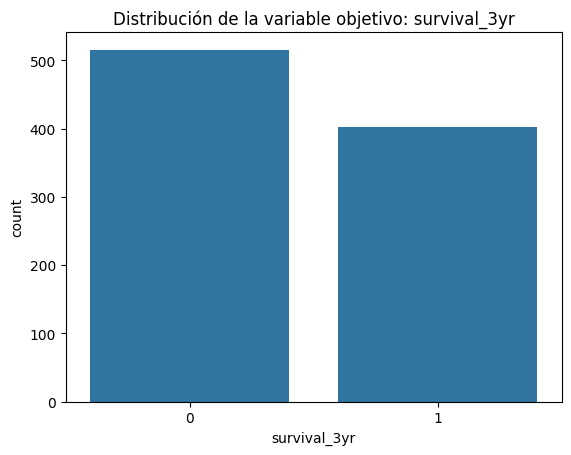

In [34]:
# Visualización de la variable objetivo
sns.countplot(x='survival_3yr', data=merged_data)
plt.title('Distribución de la variable objetivo: survival_3yr')
plt.show()

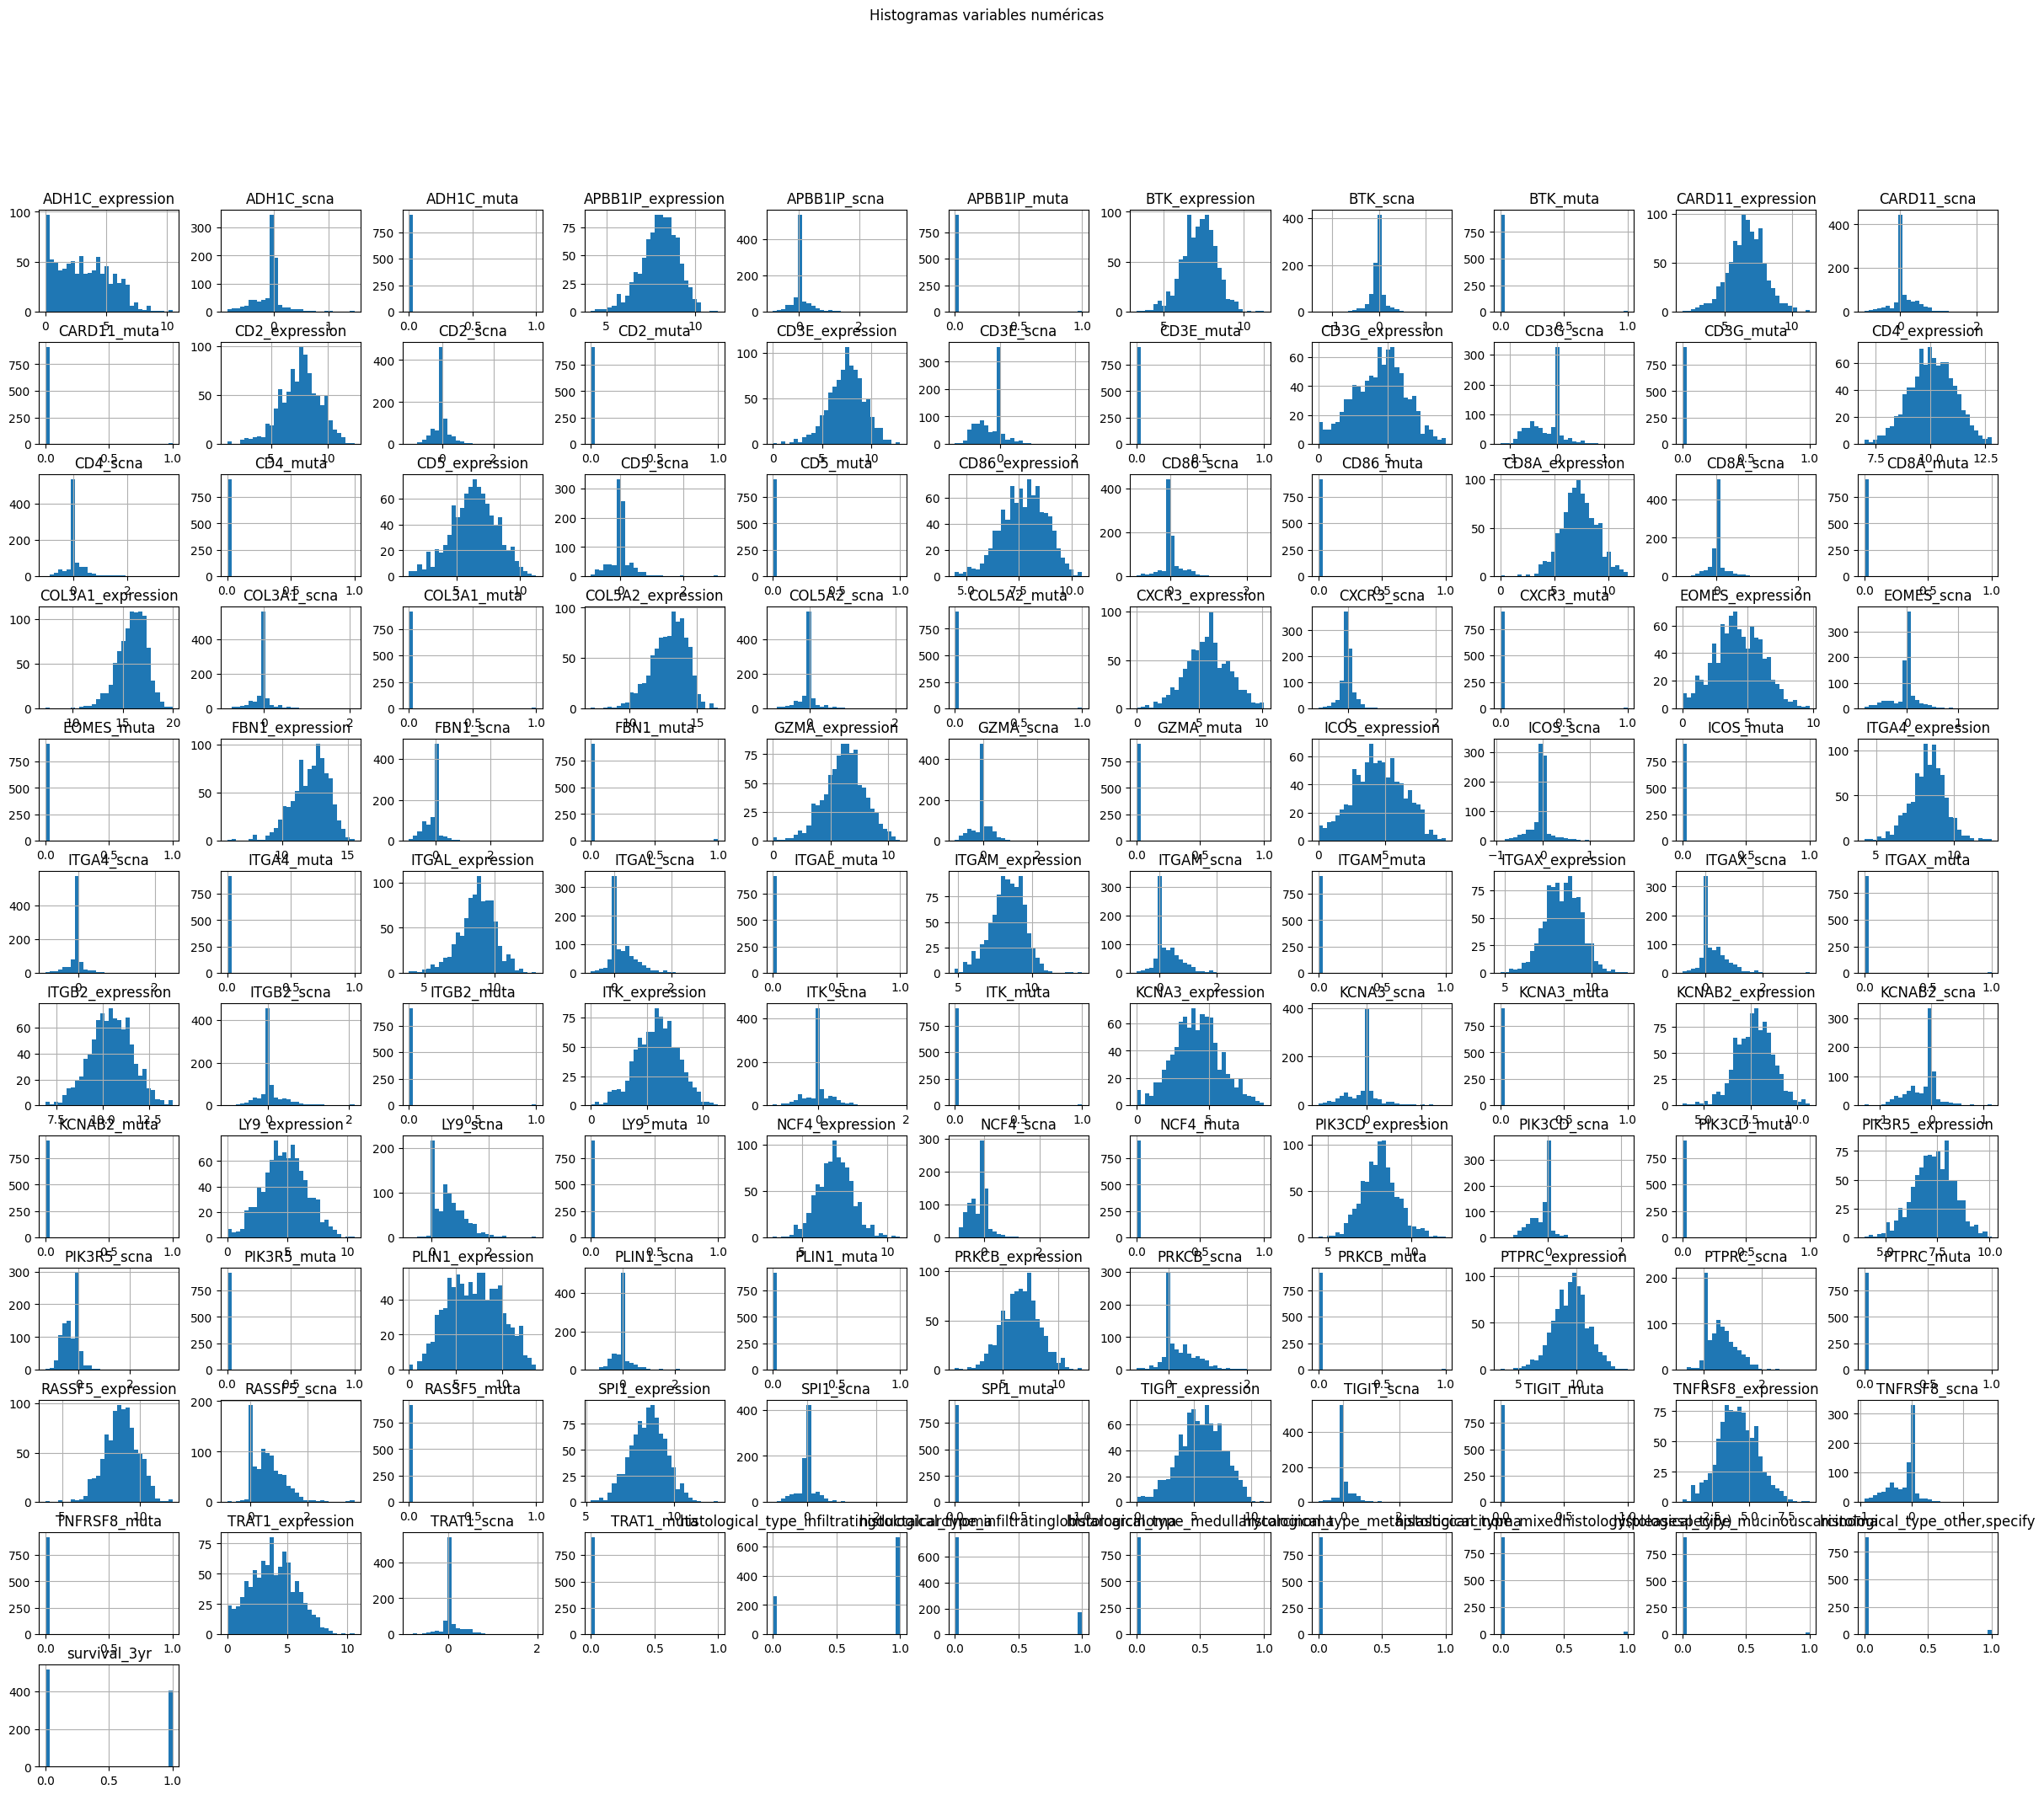

In [35]:
merged_data.hist(bins=30, figsize=(30, 24))
plt.suptitle('Histogramas variables numéricas')
plt.show()

Con estos gráficos se muestran ciertos patrones, donde la expresión de los genes suele tener la mayor cantidad de valores centralizada, casi simétrica. Los scna por otro lado poseen picos de cantidad de variables con un valor semejante en la zona izquuierda del gráfico. Las mutaciones están ausentes en la mayoría de los casos.

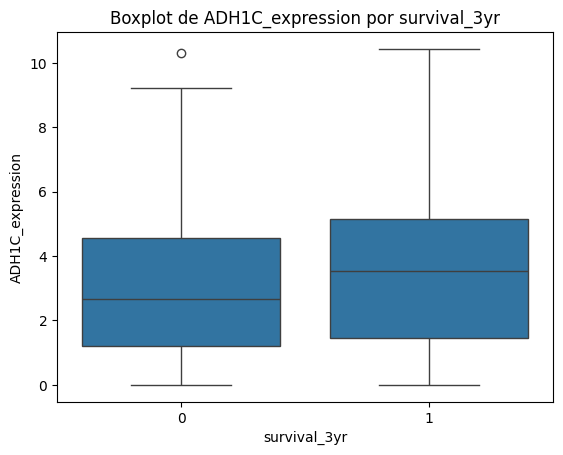

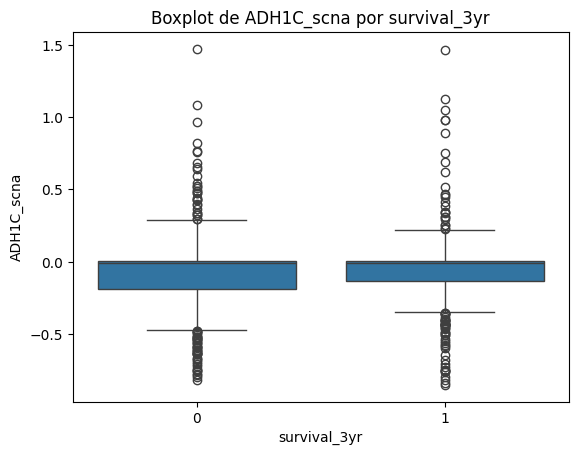

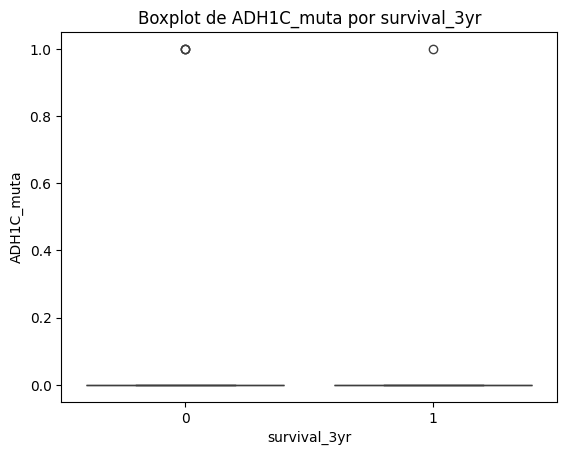

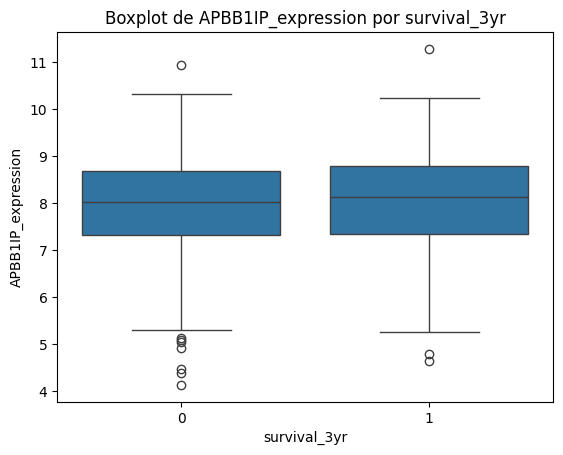

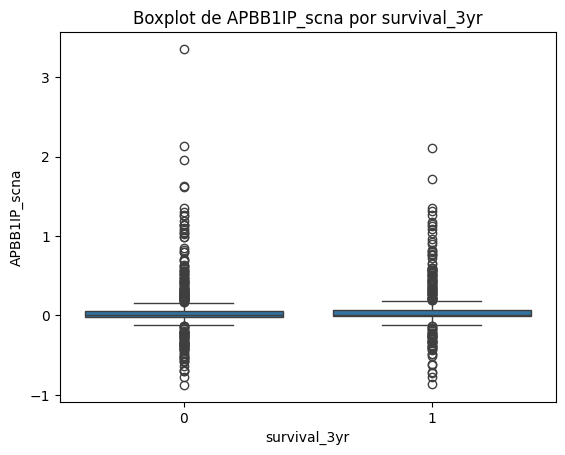

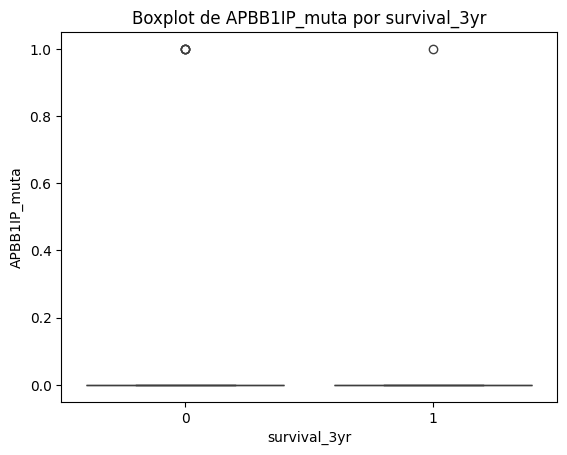

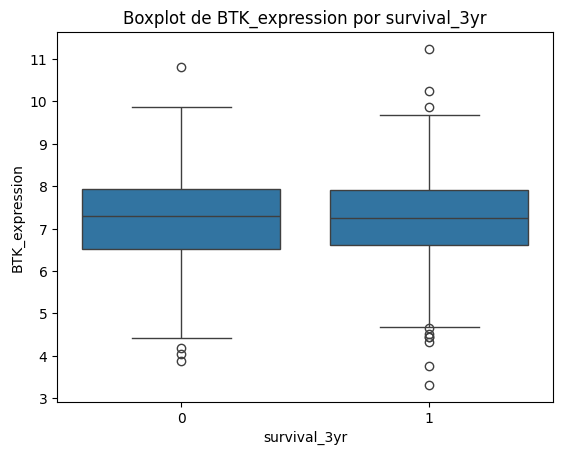

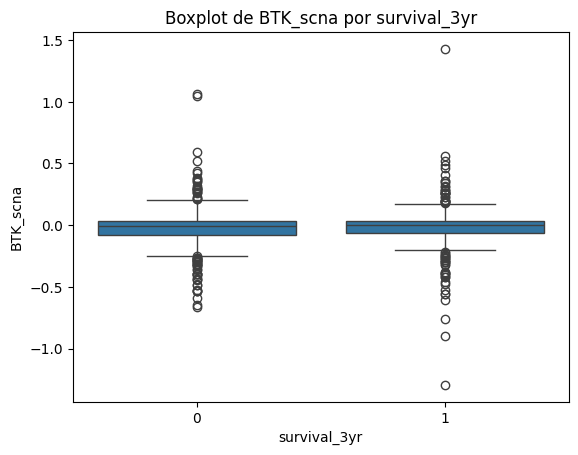

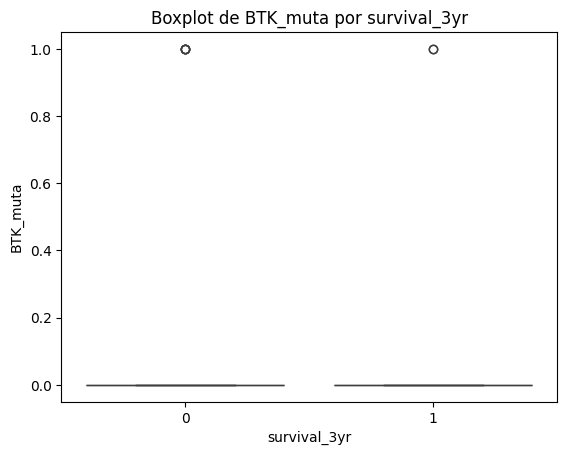

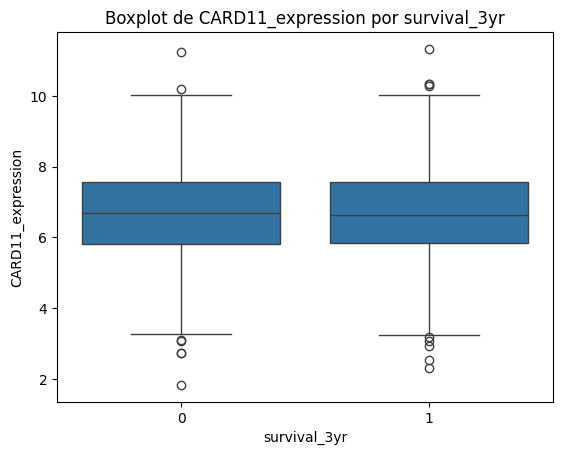

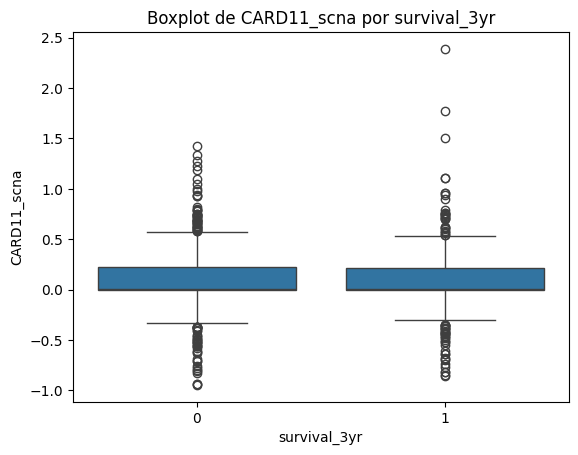

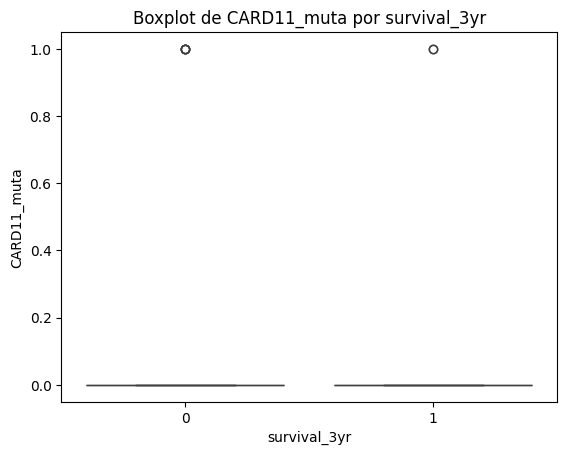

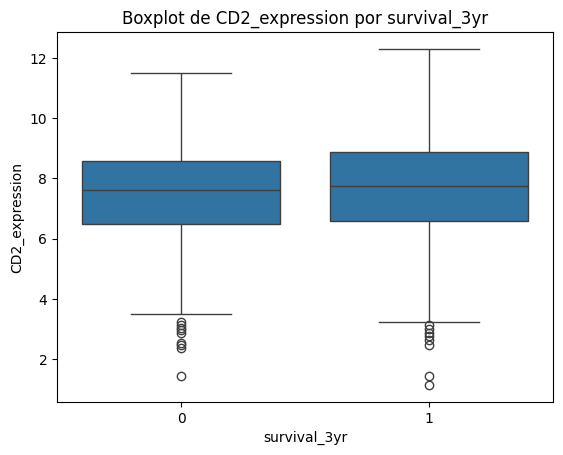

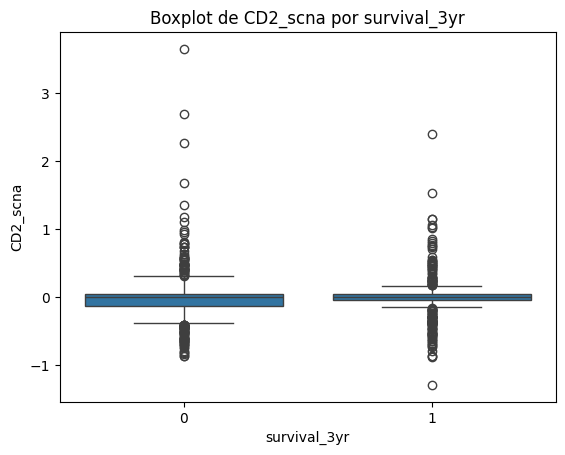

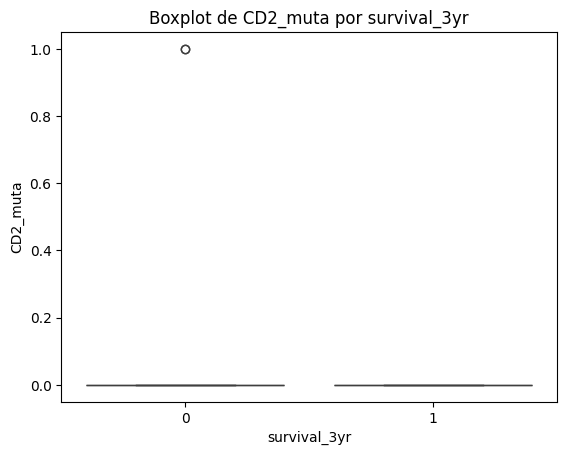

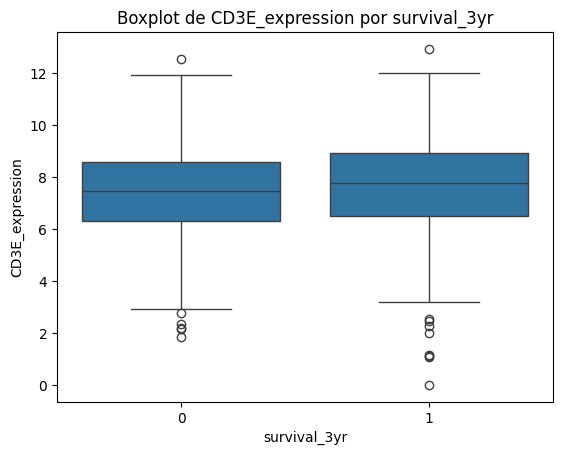

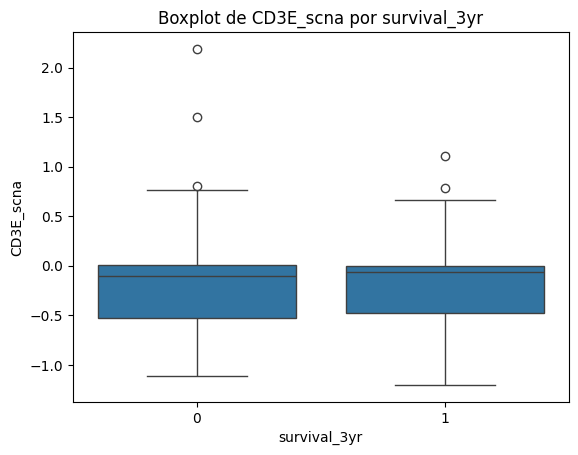

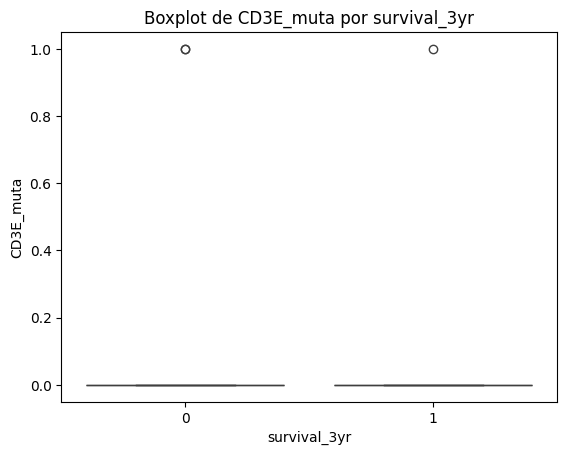

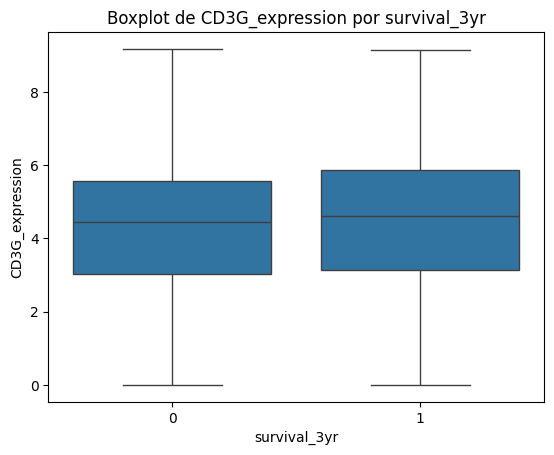

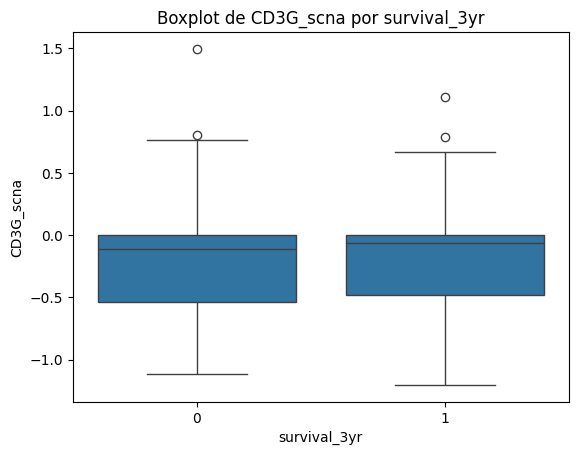

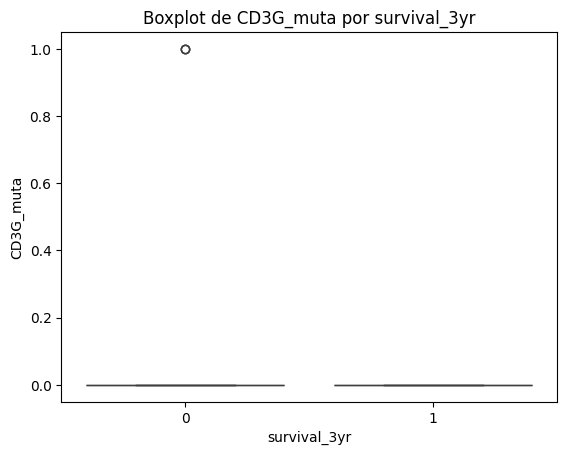

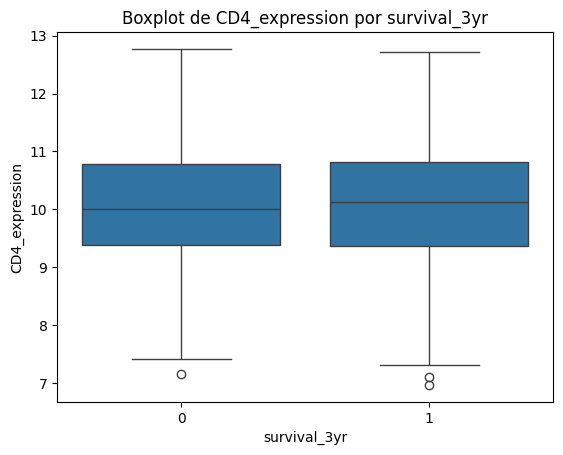

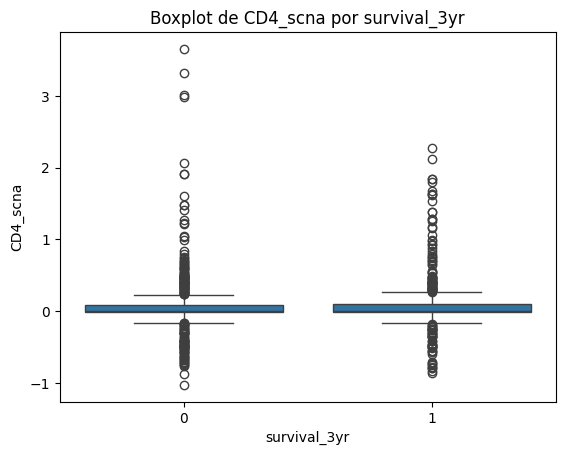

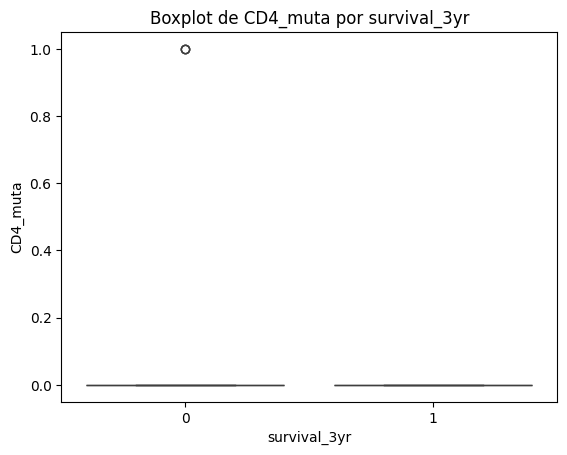

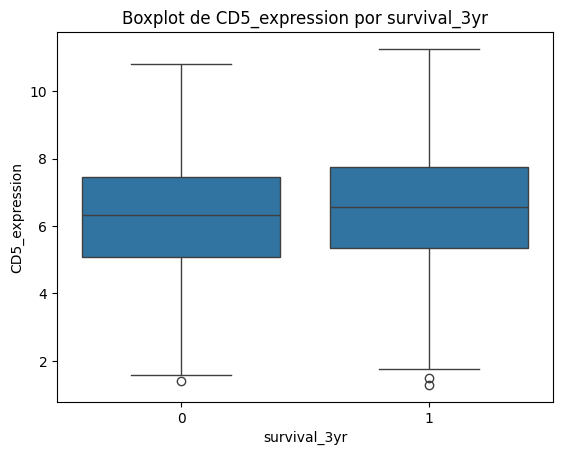

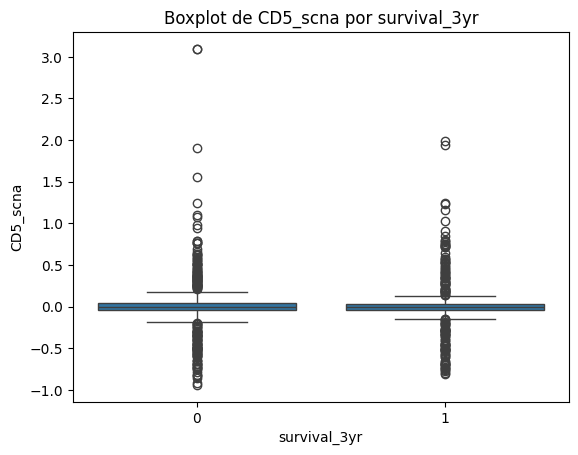

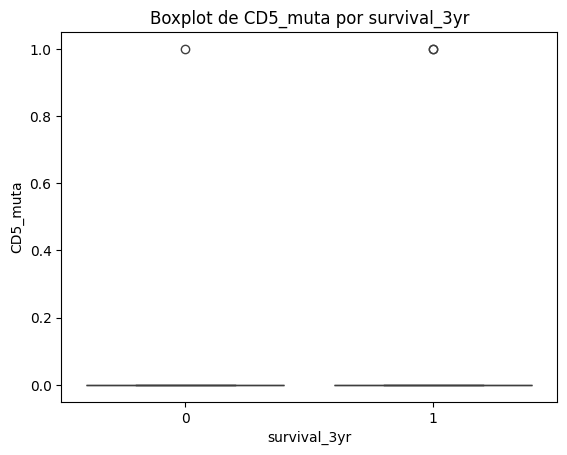

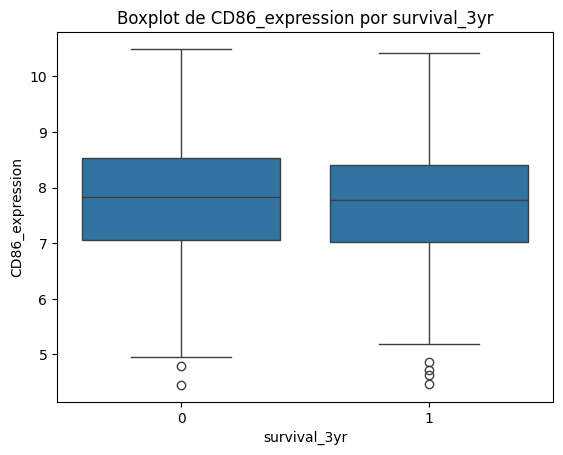

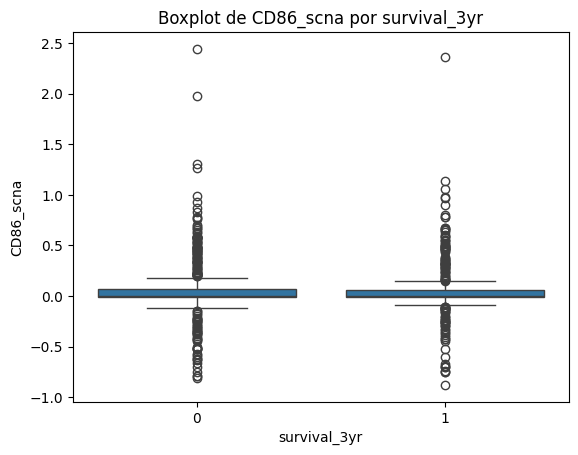

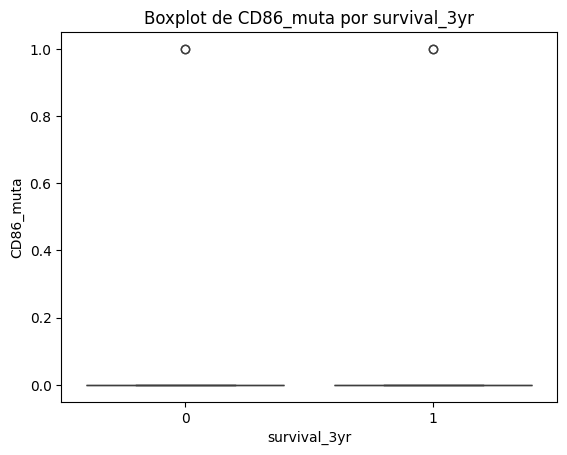

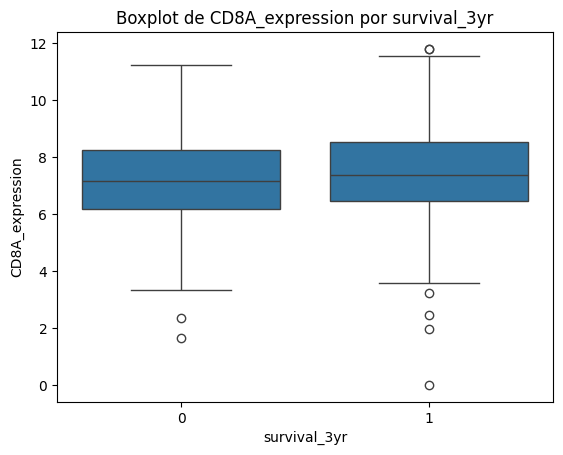

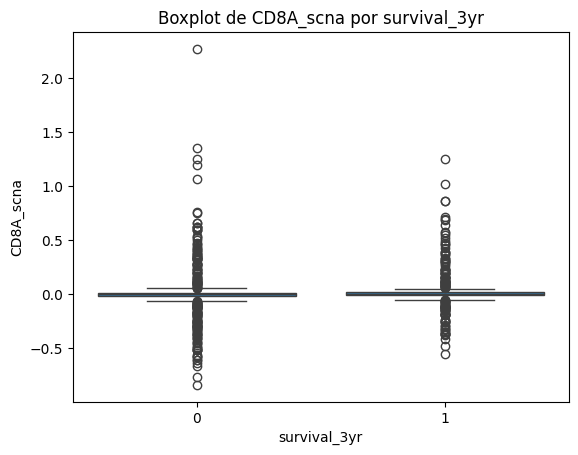

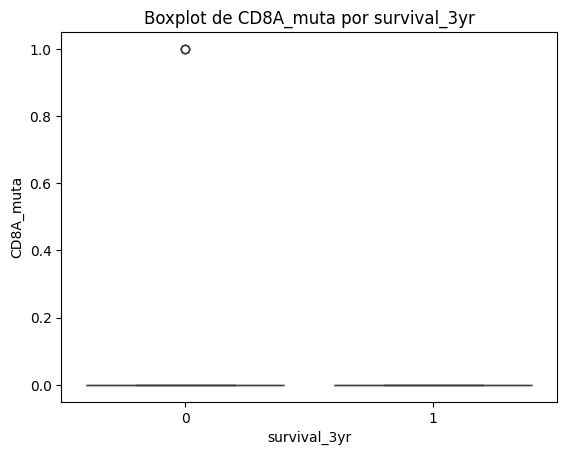

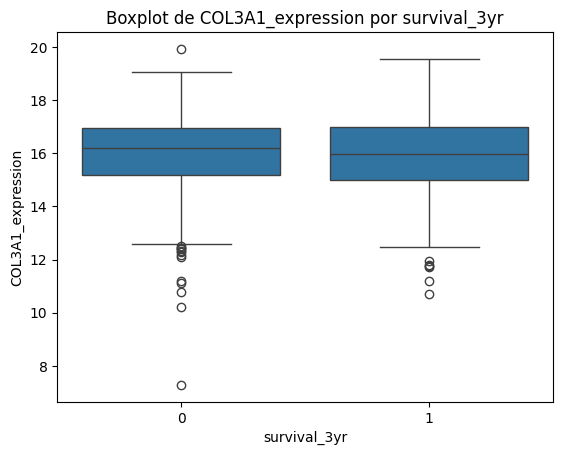

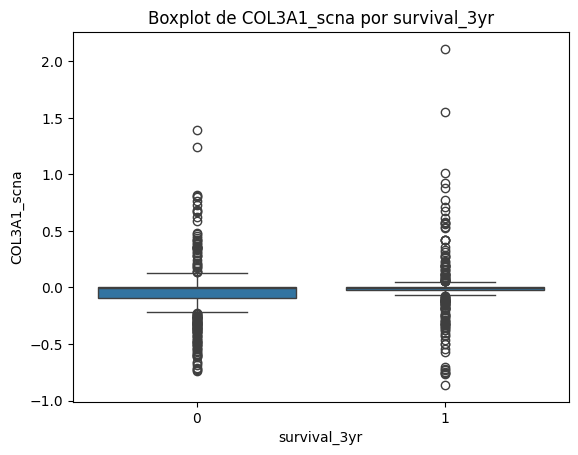

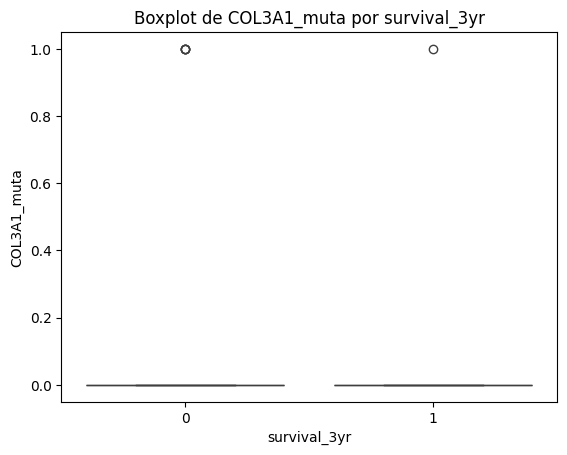

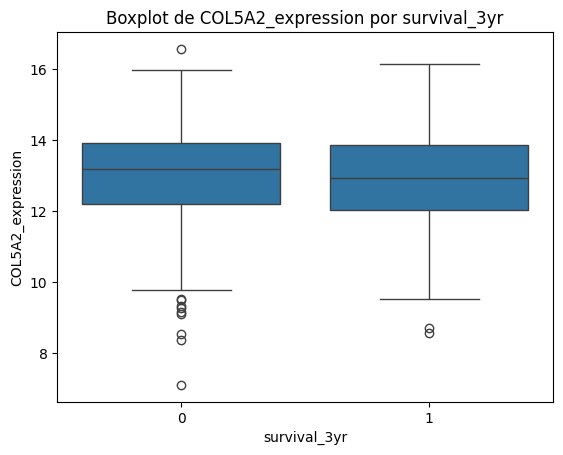

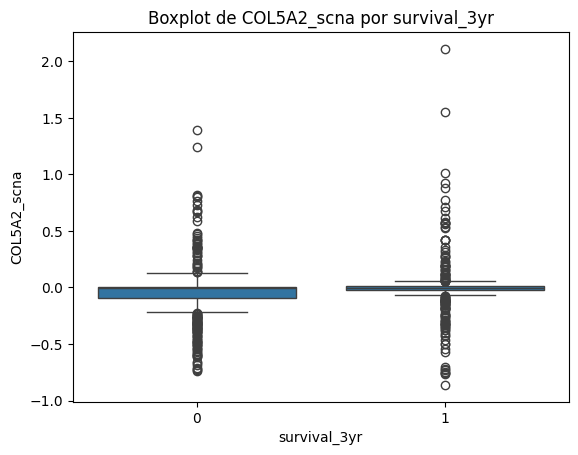

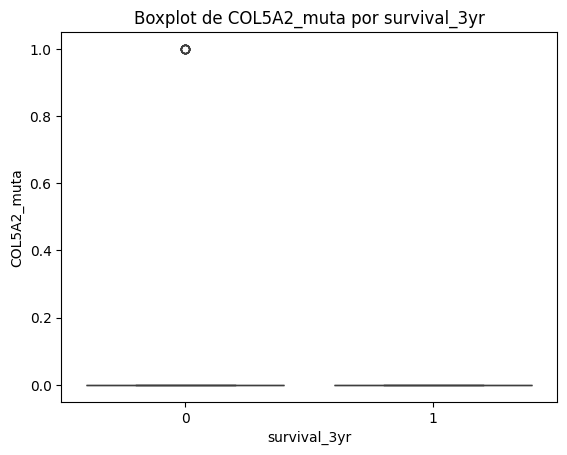

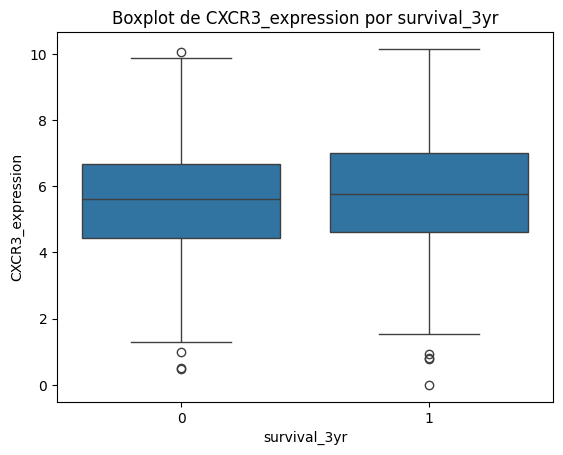

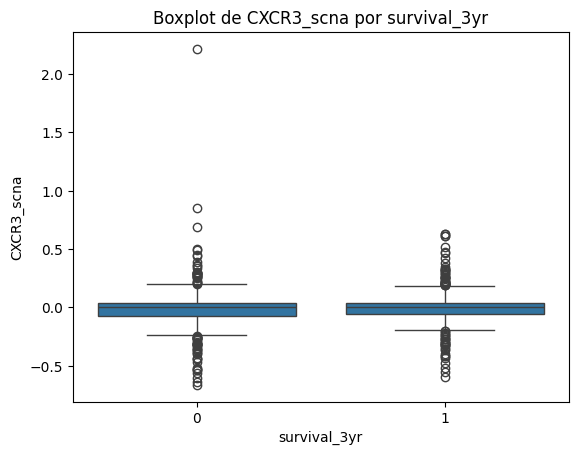

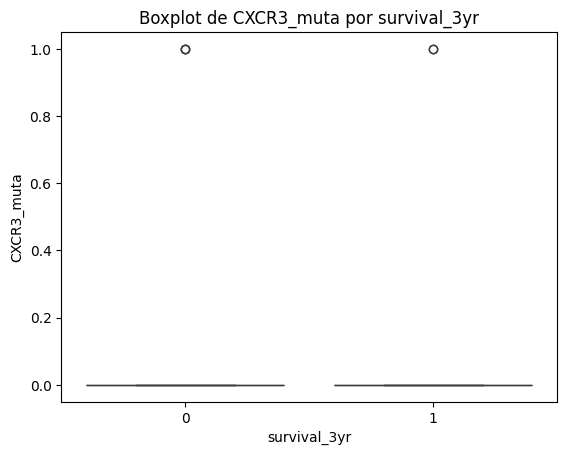

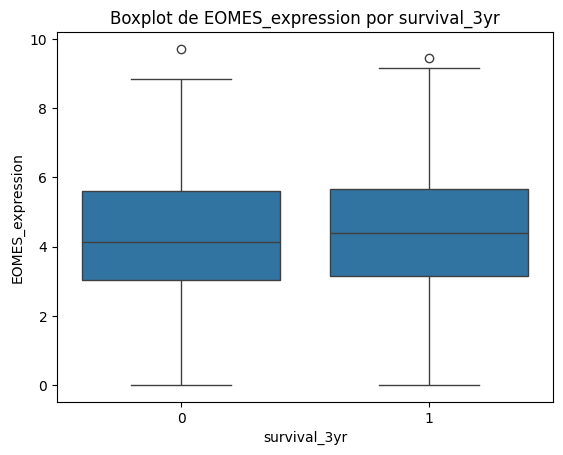

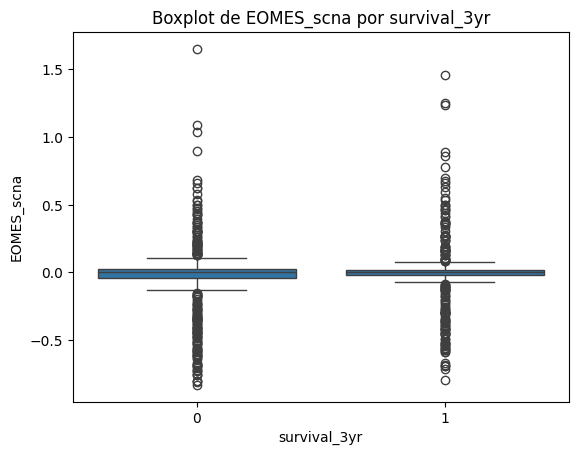

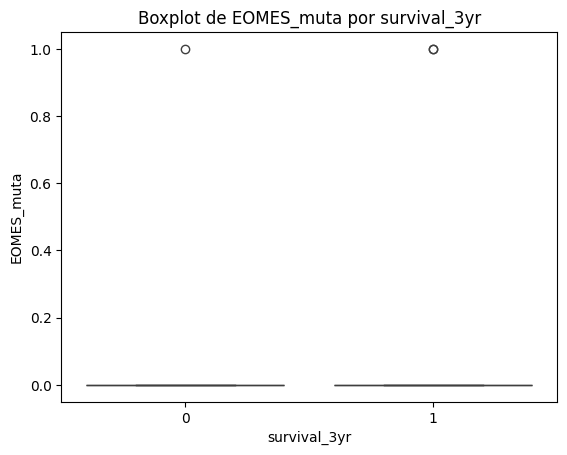

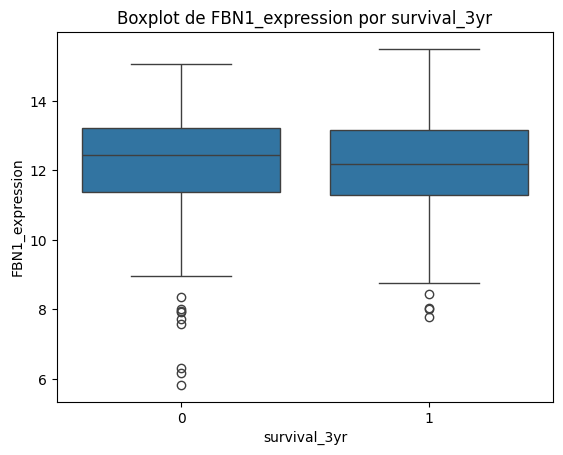

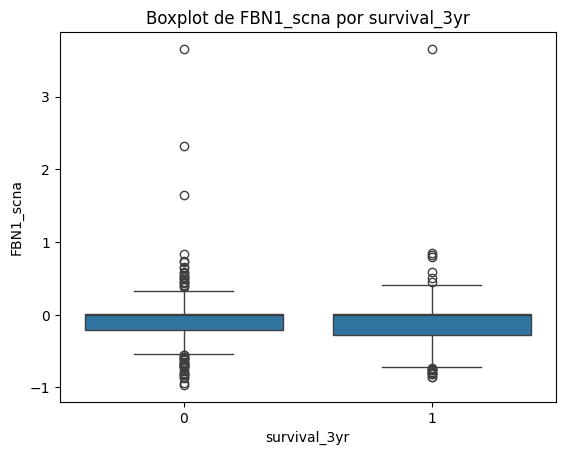

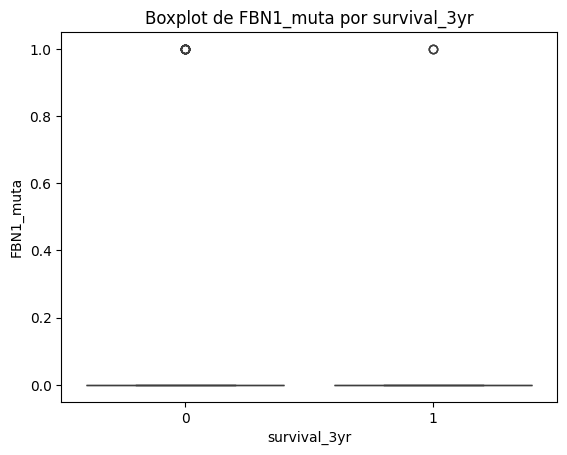

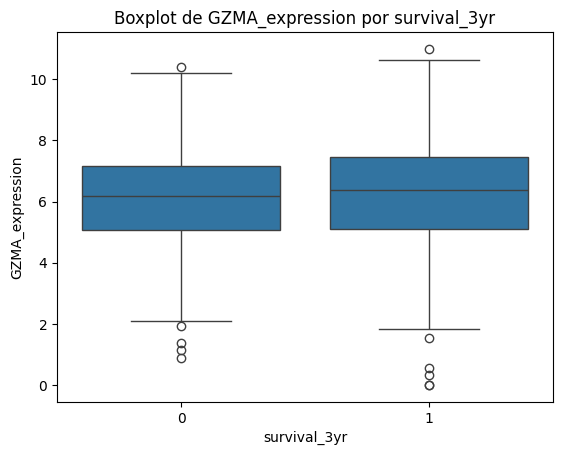

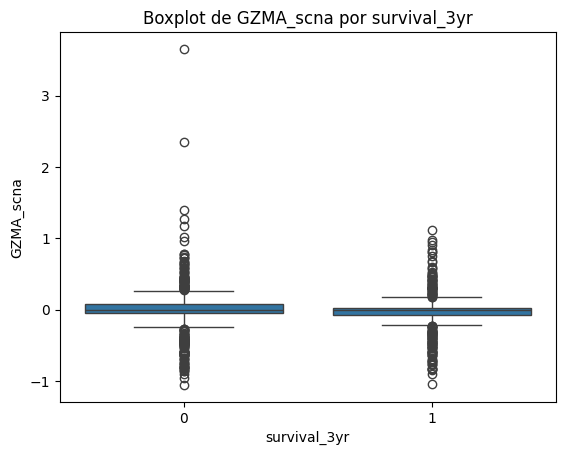

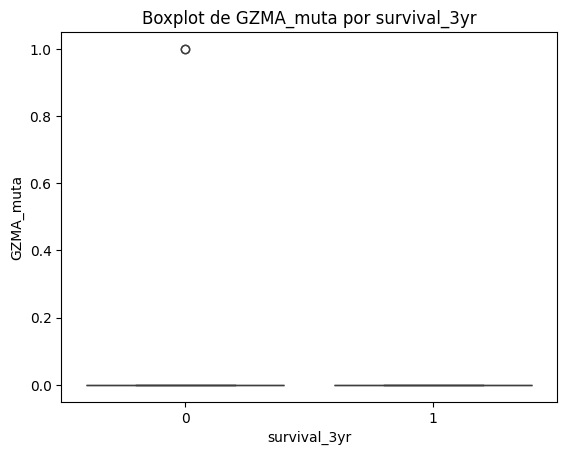

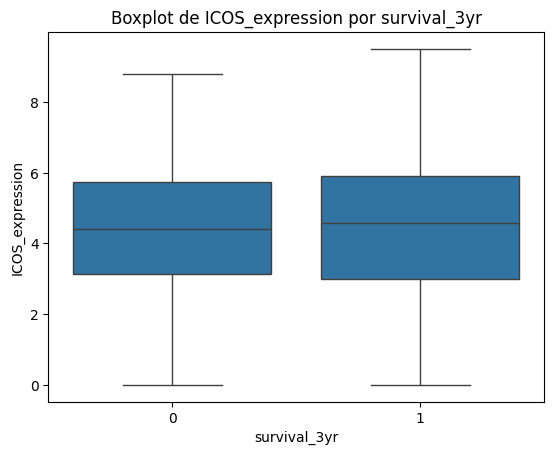

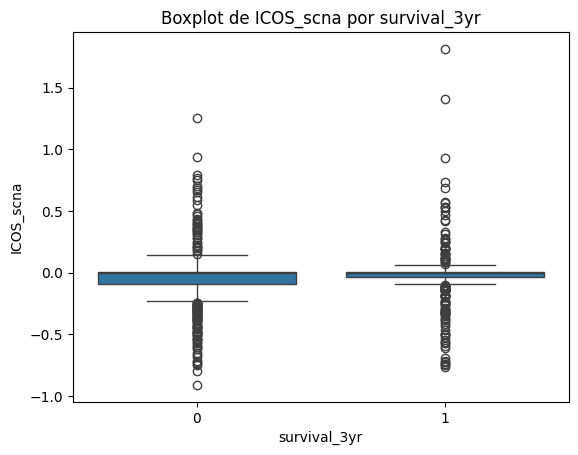

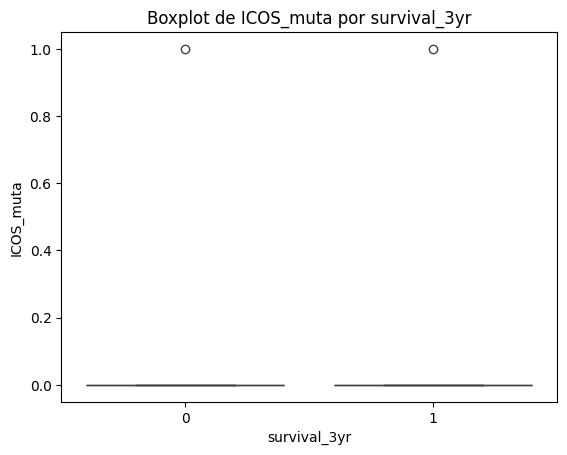

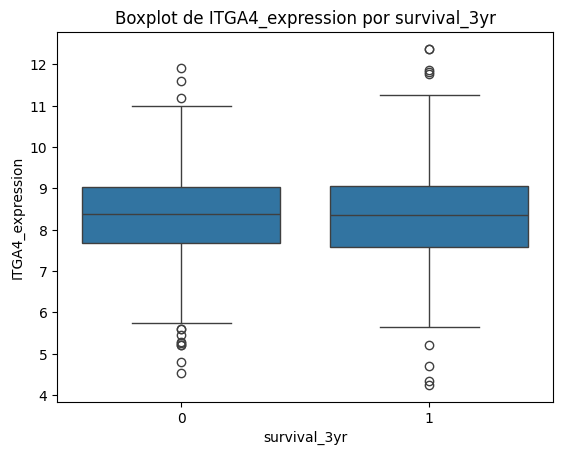

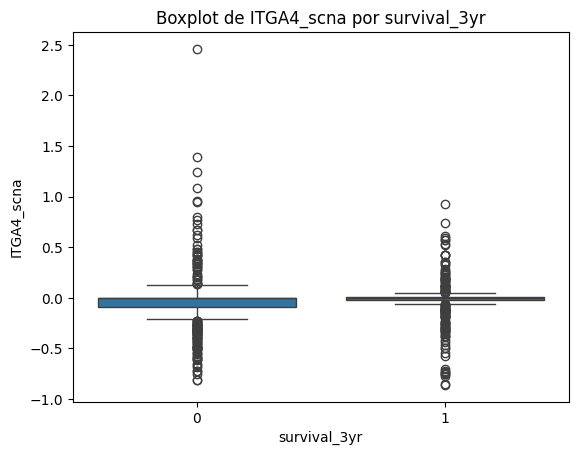

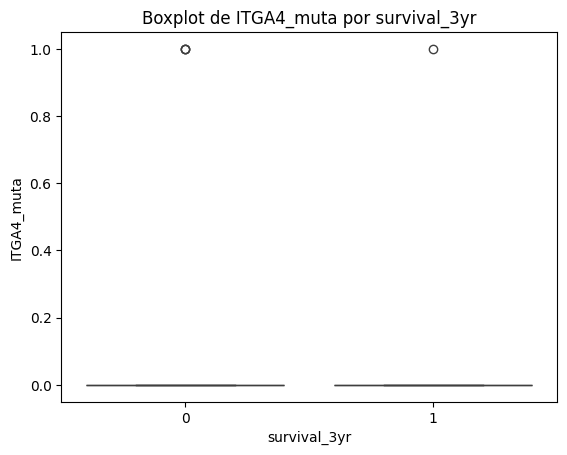

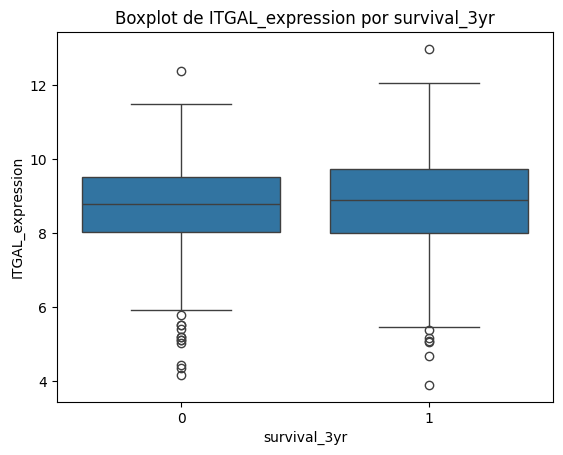

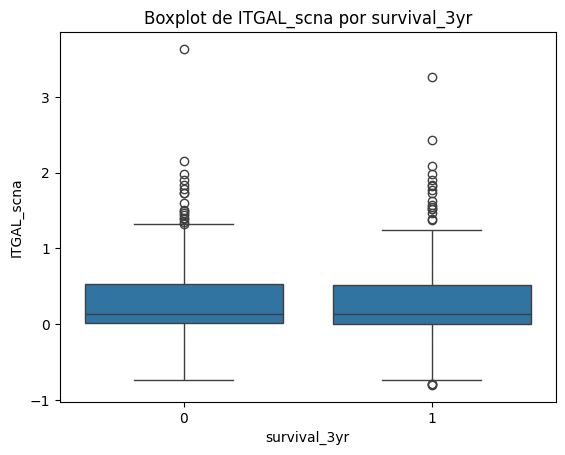

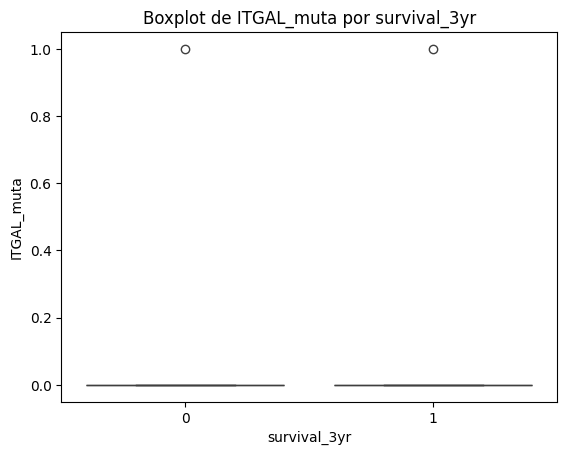

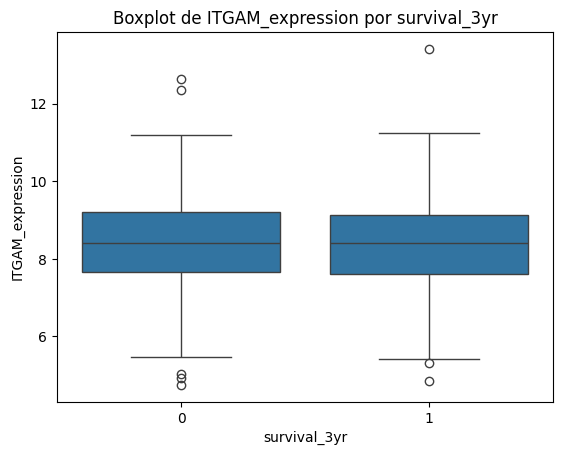

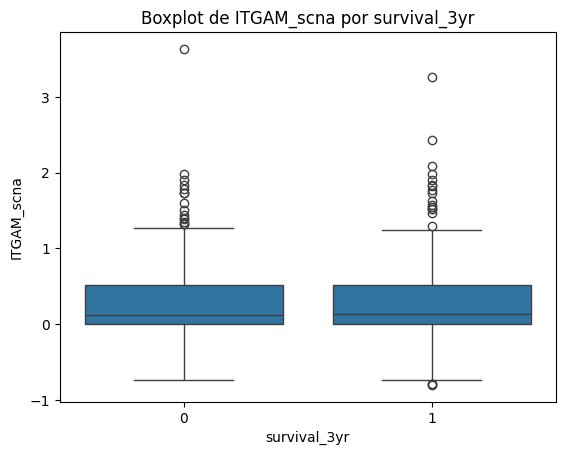

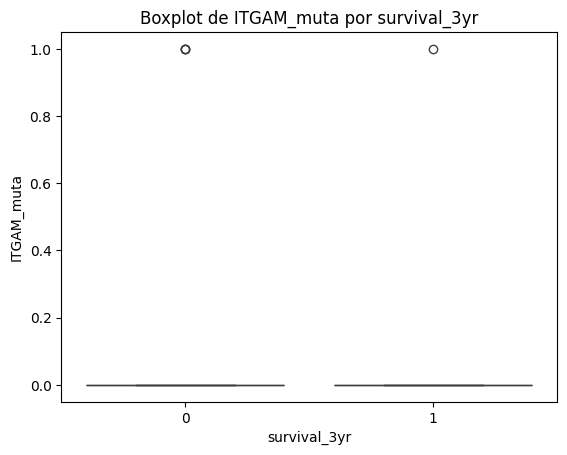

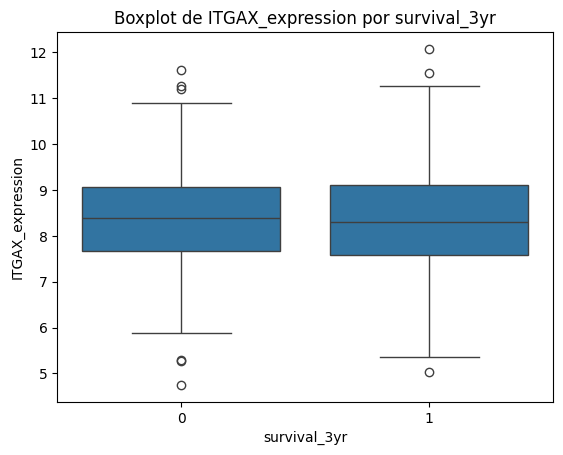

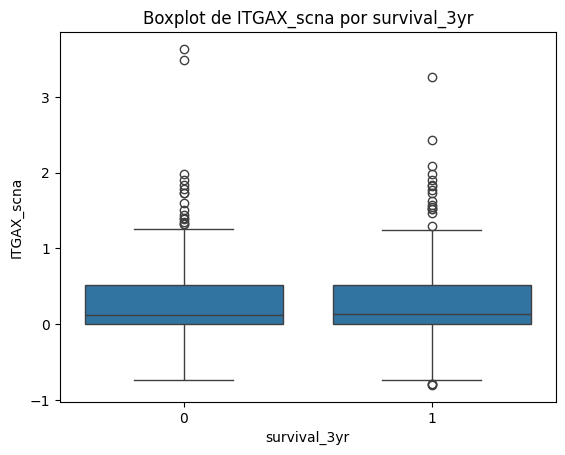

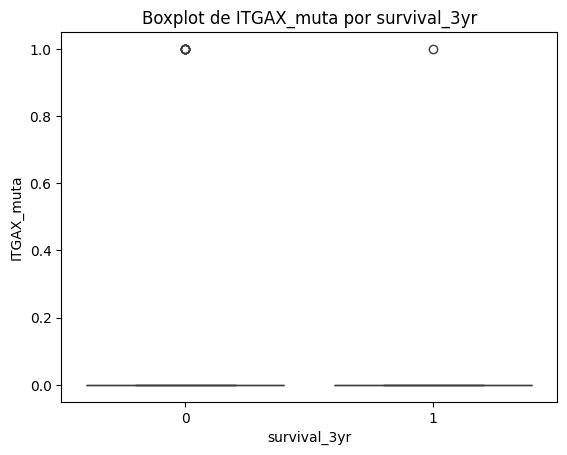

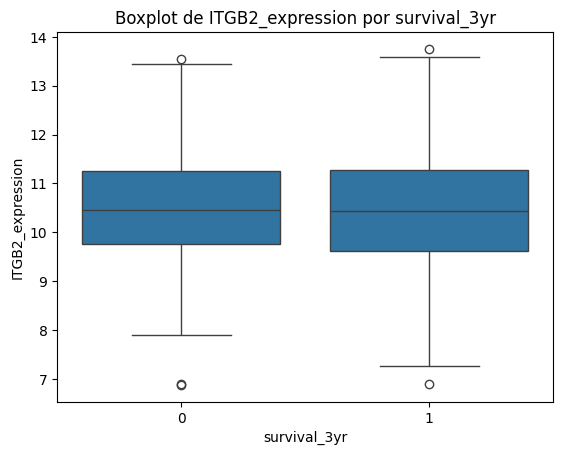

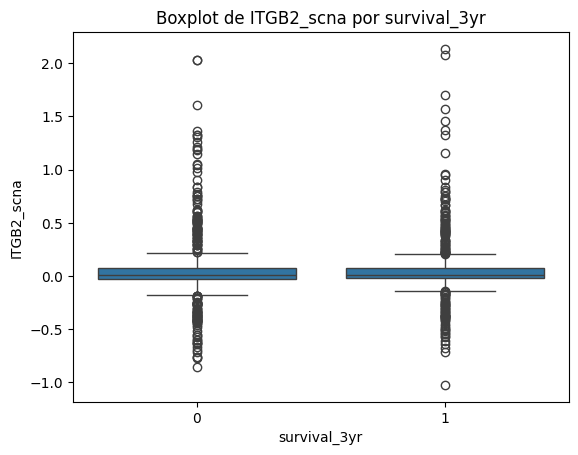

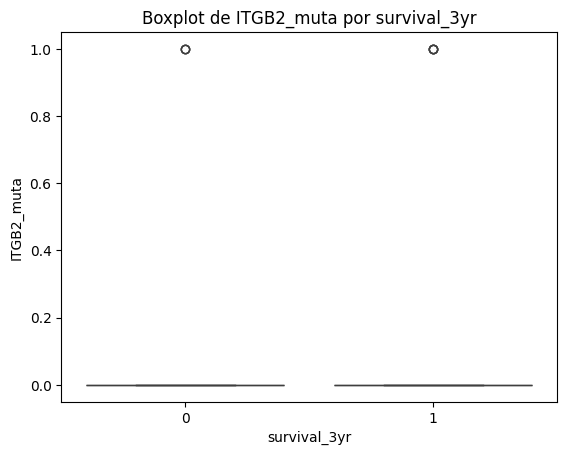

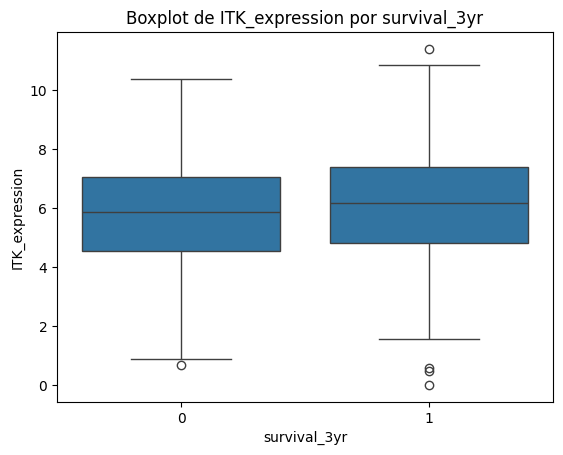

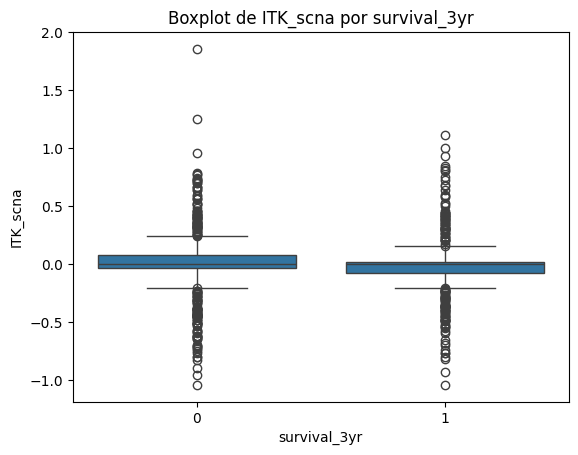

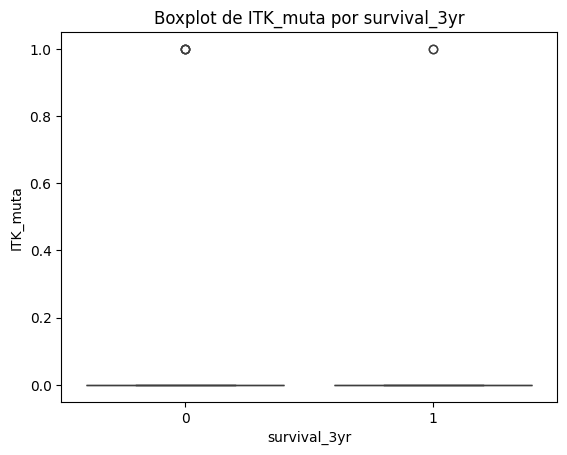

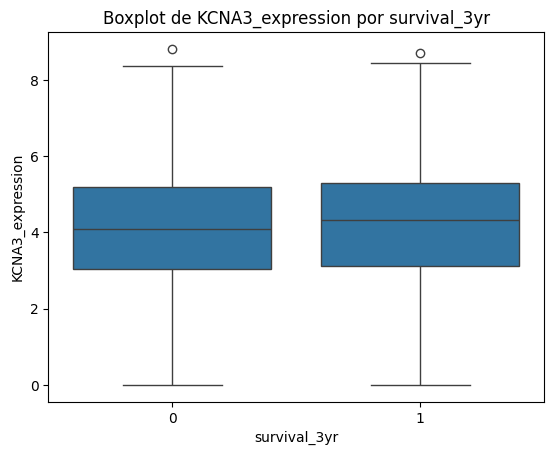

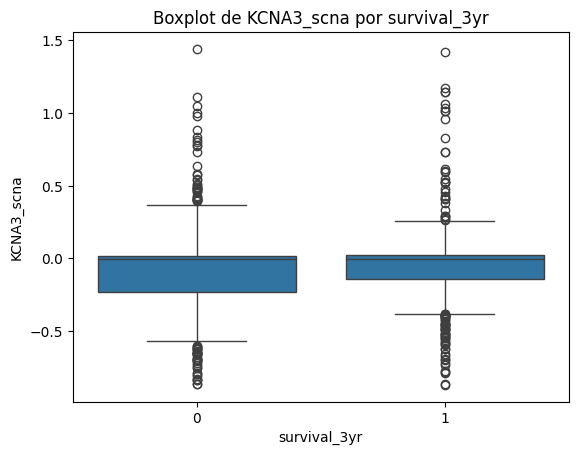

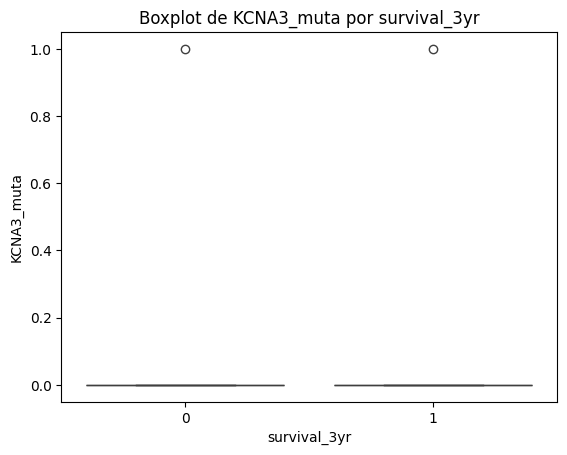

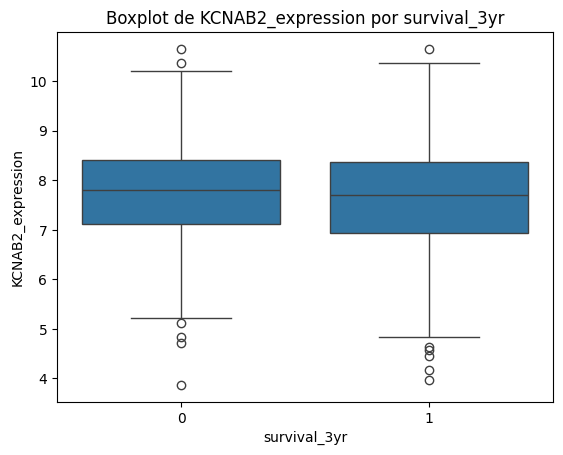

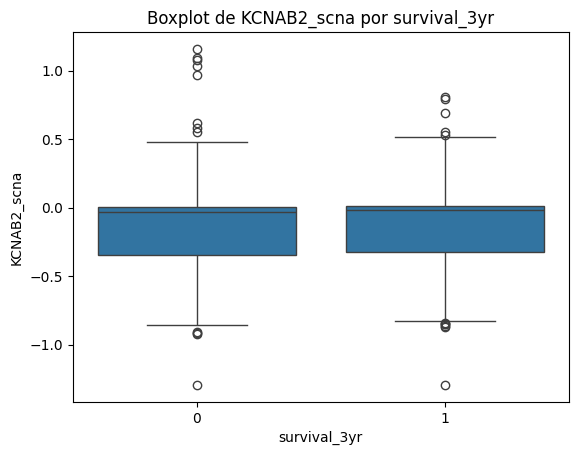

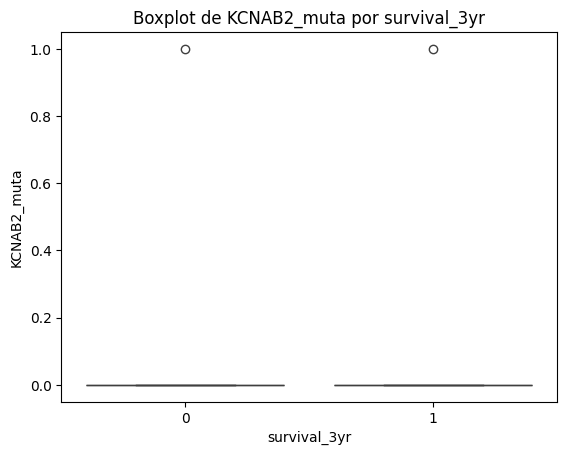

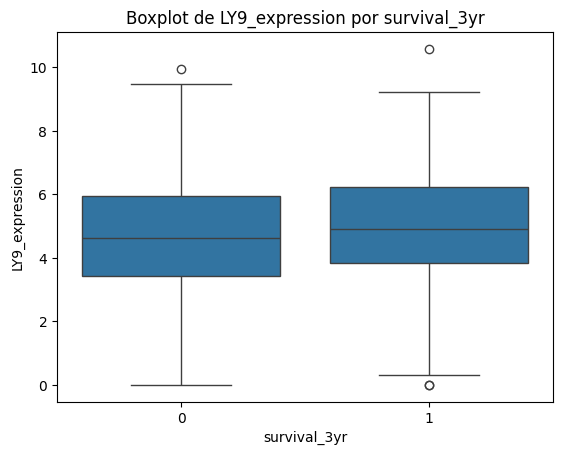

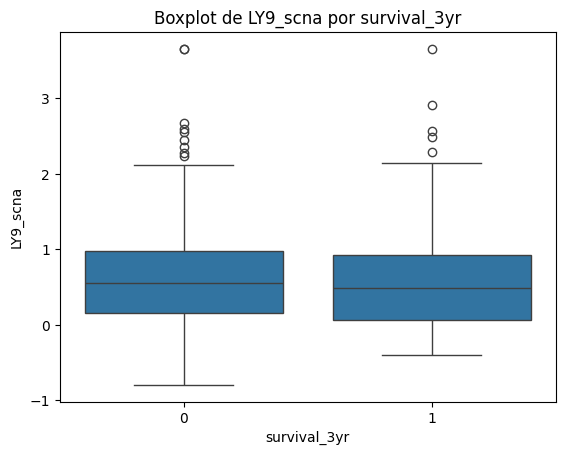

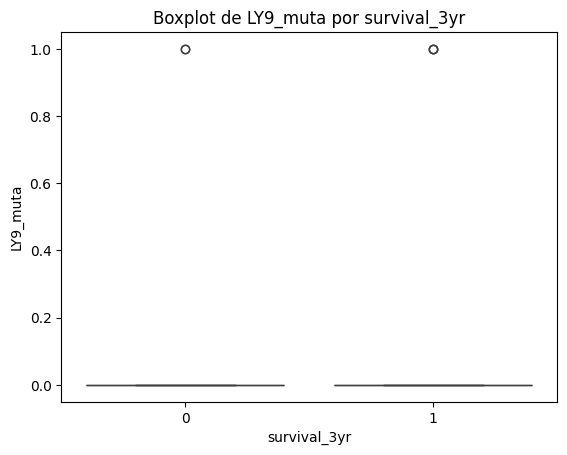

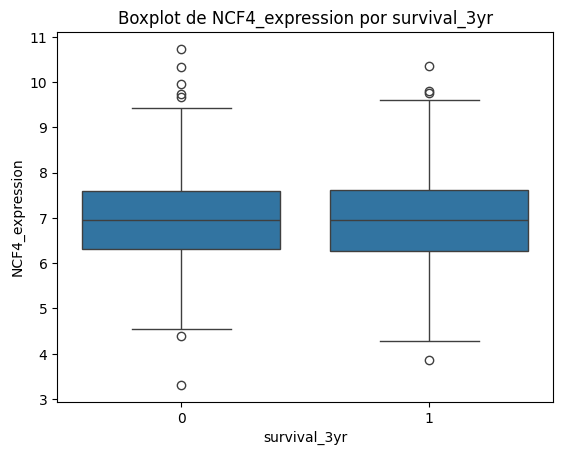

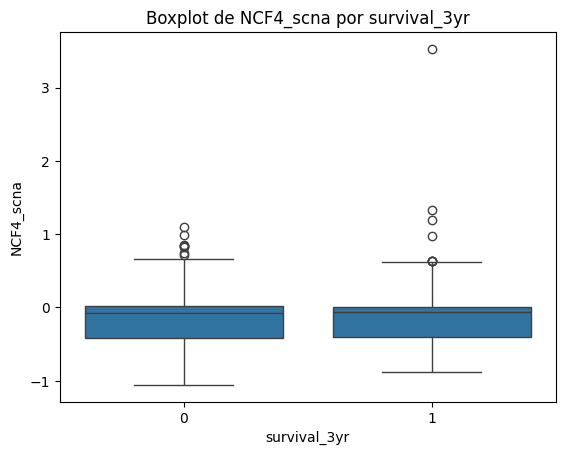

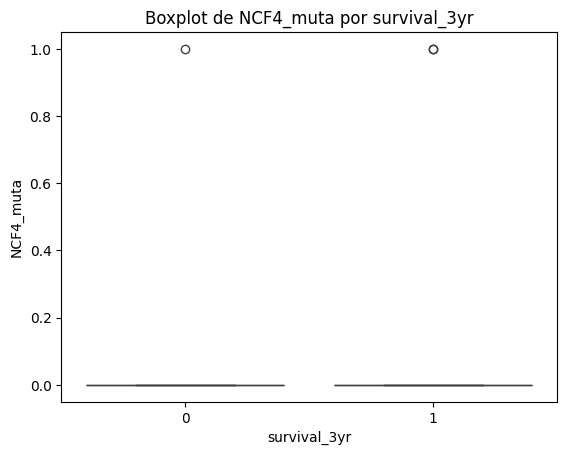

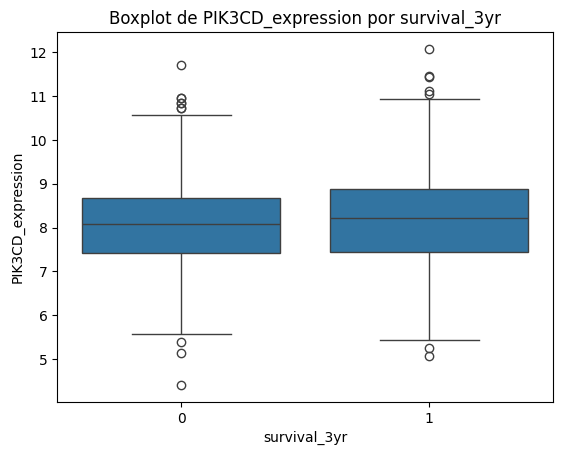

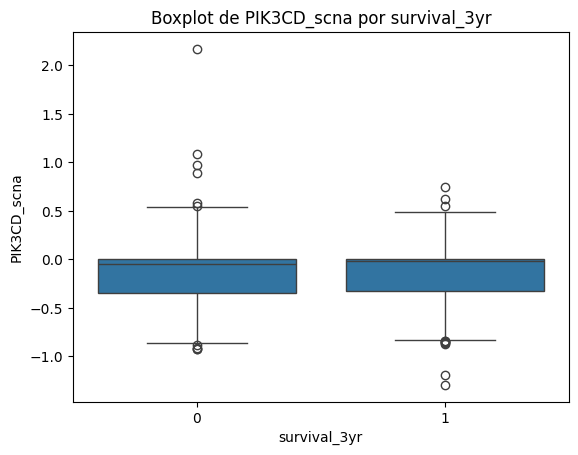

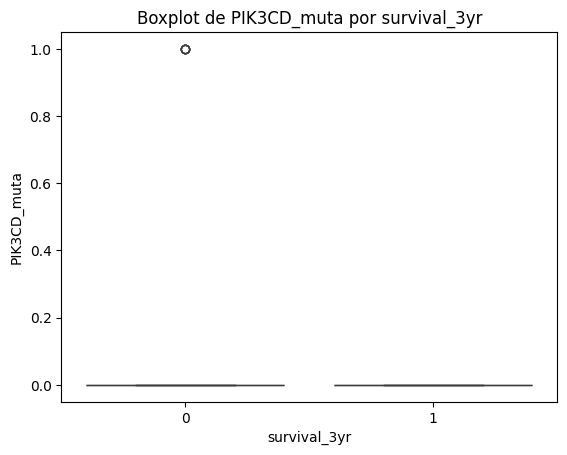

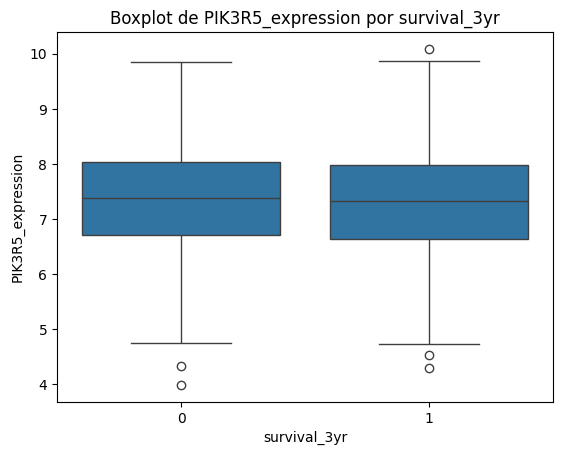

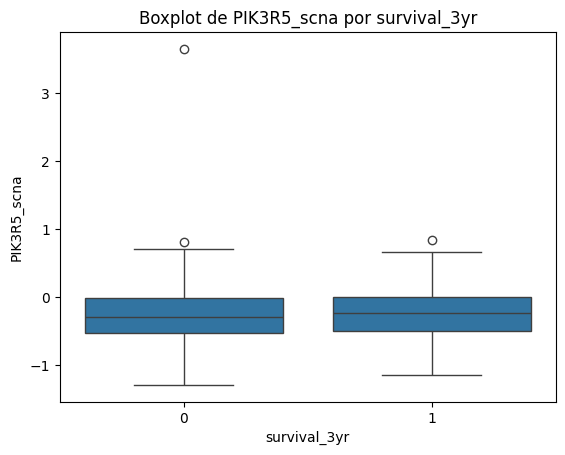

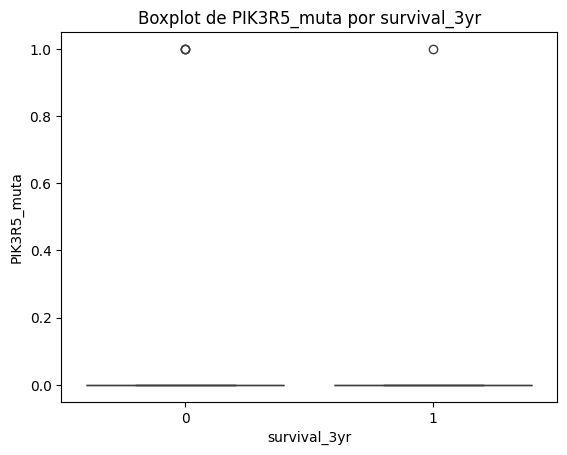

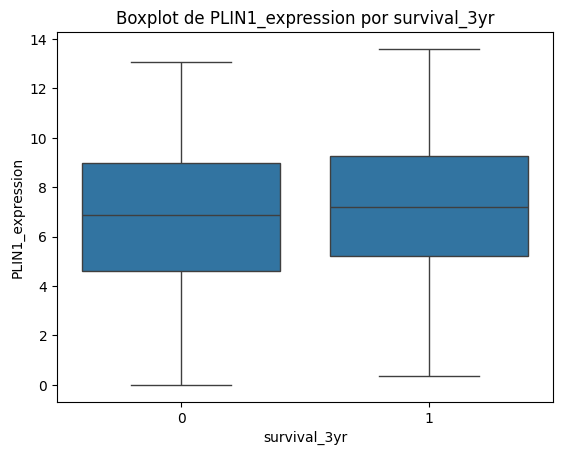

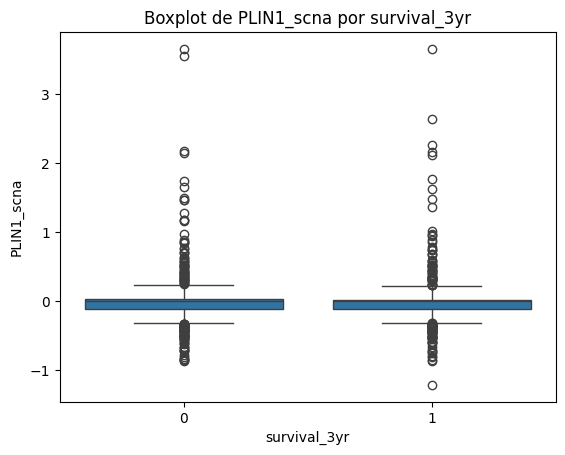

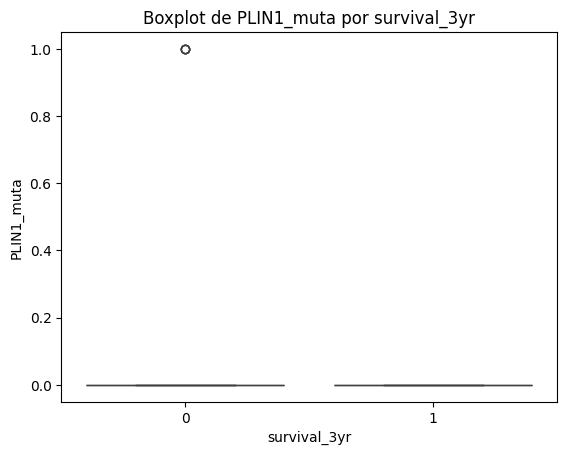

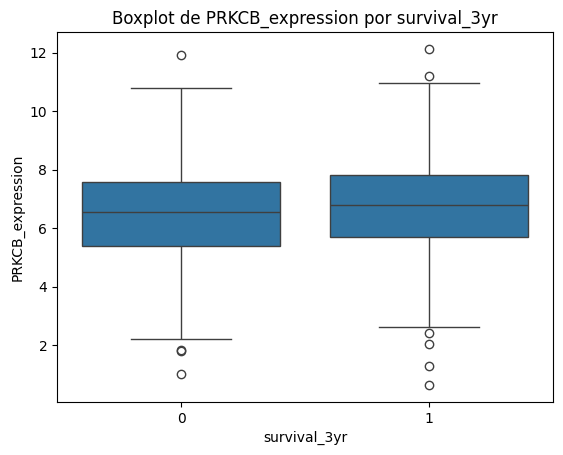

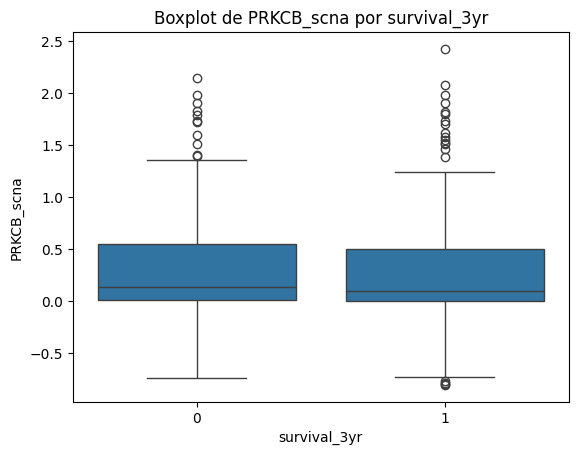

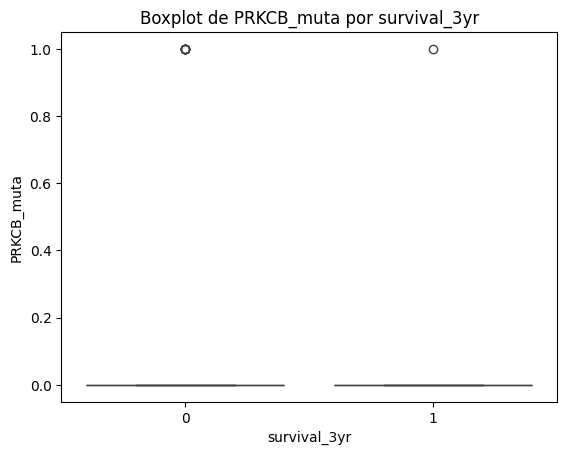

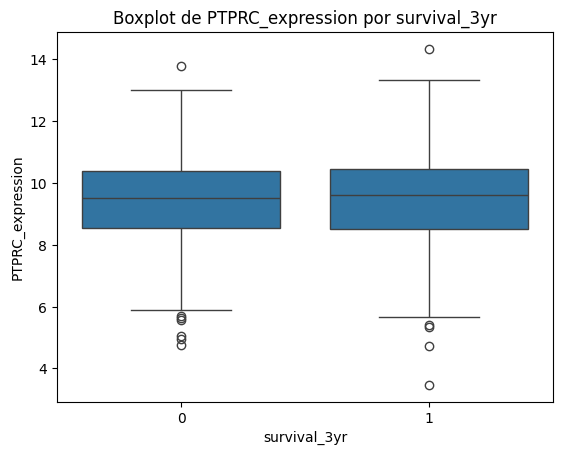

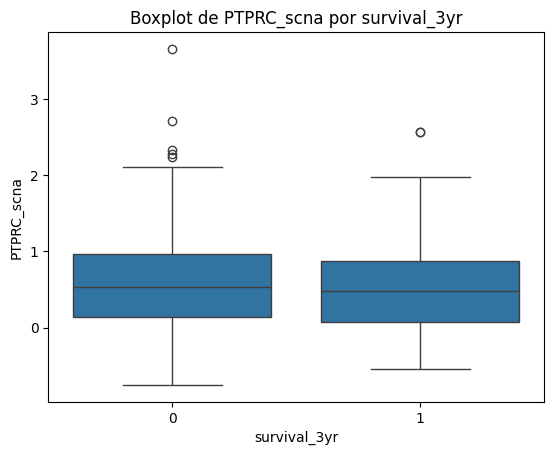

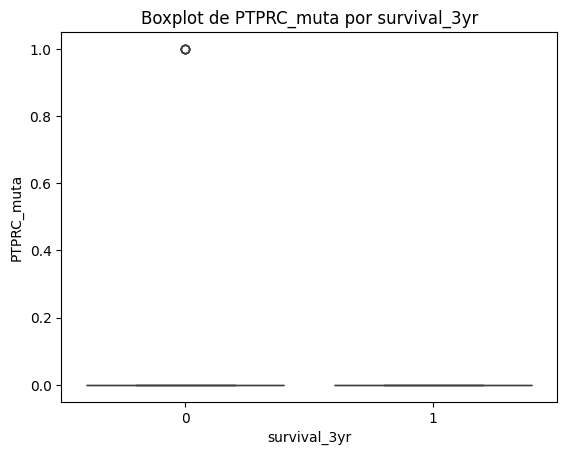

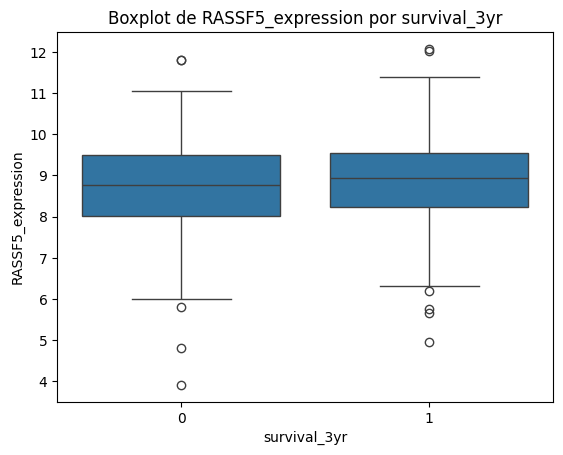

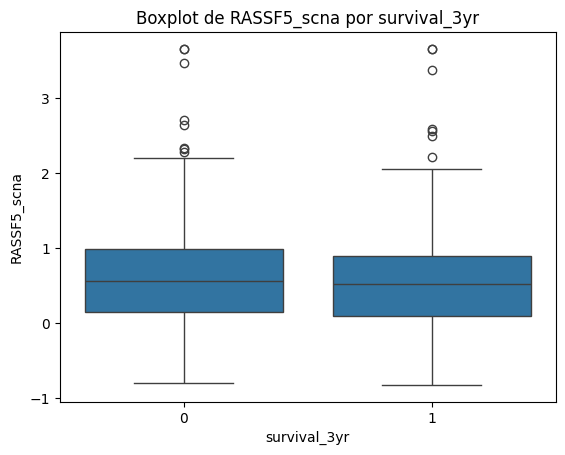

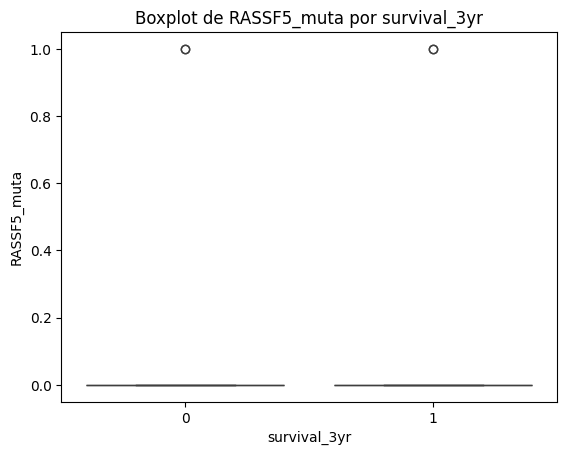

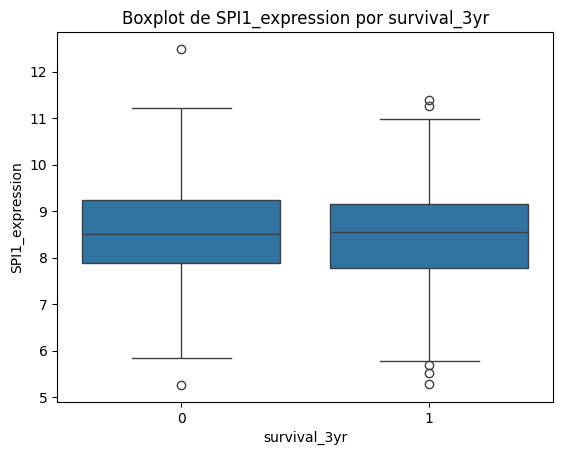

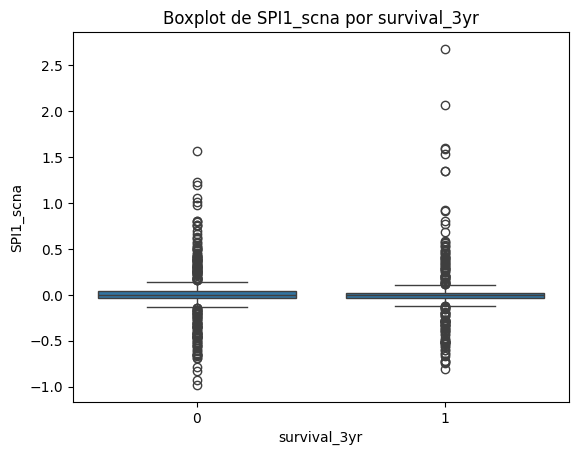

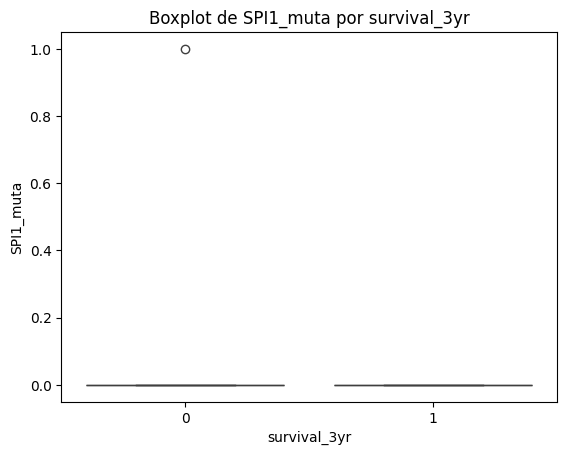

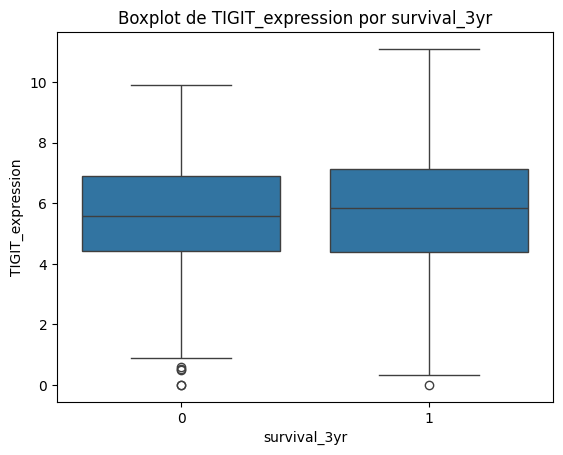

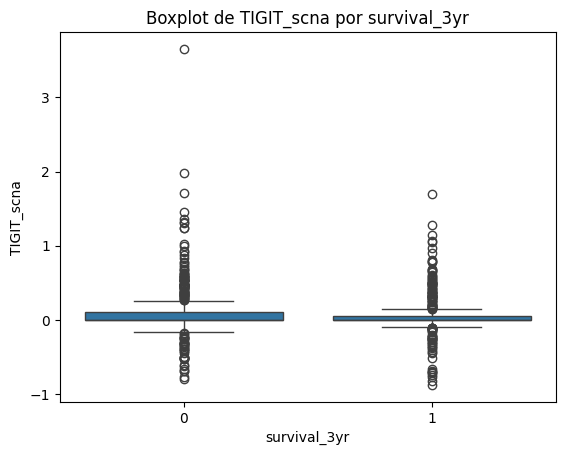

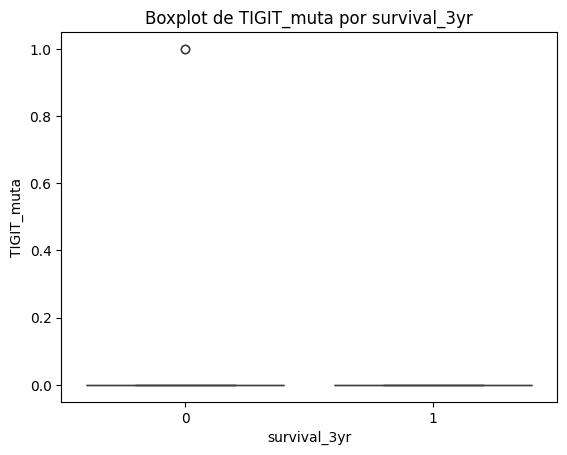

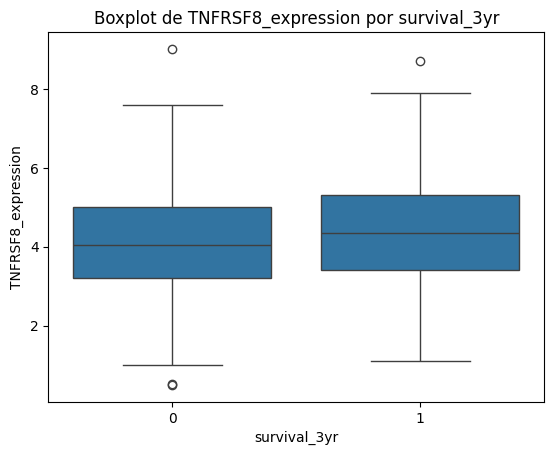

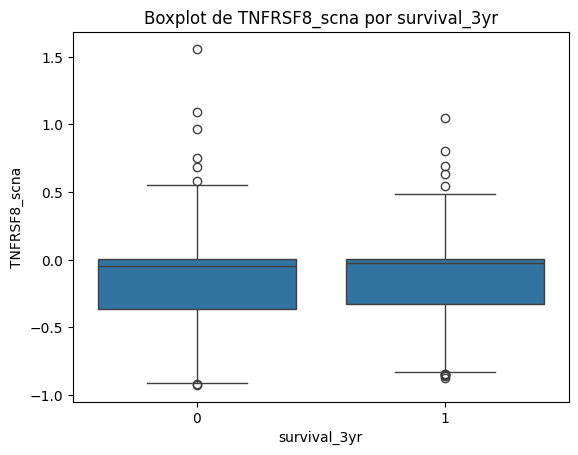

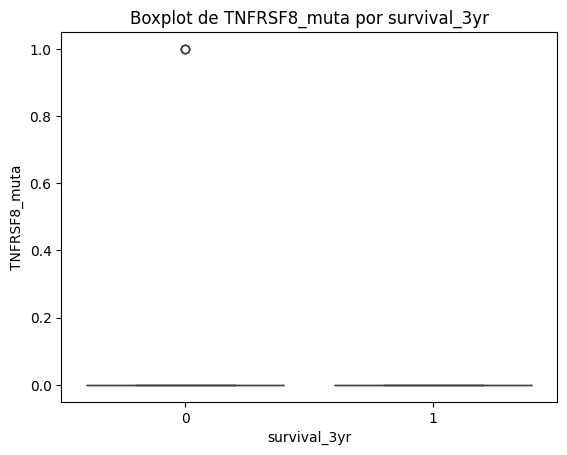

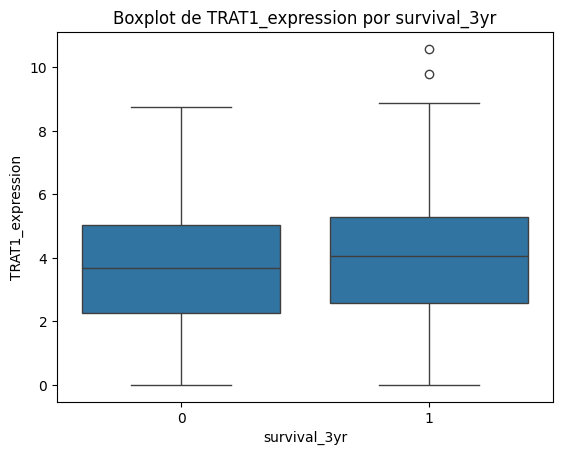

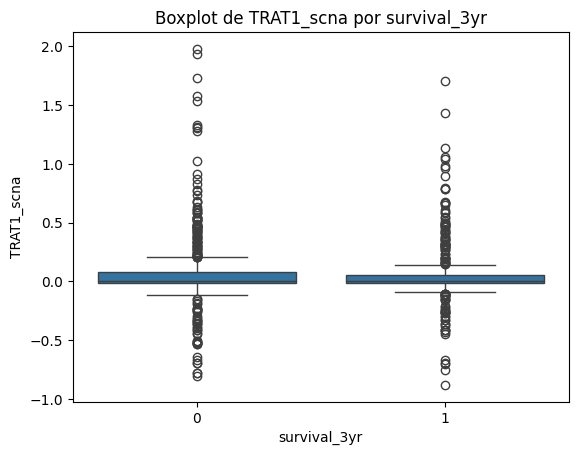

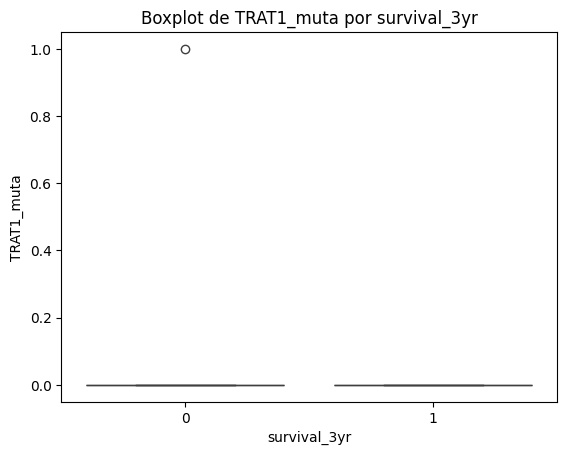

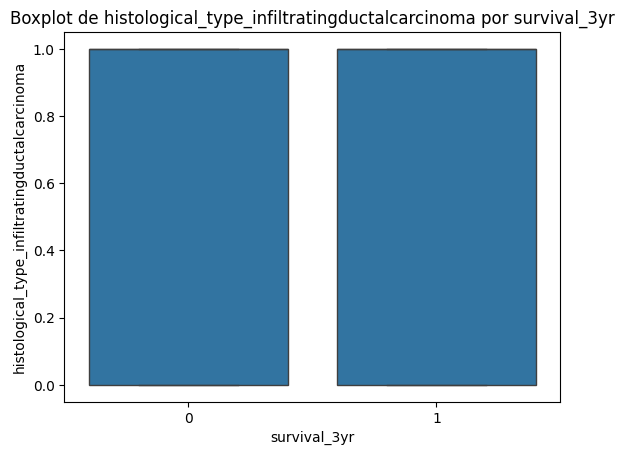

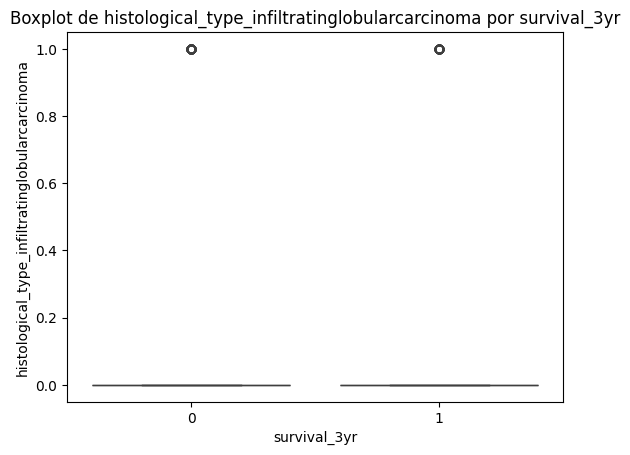

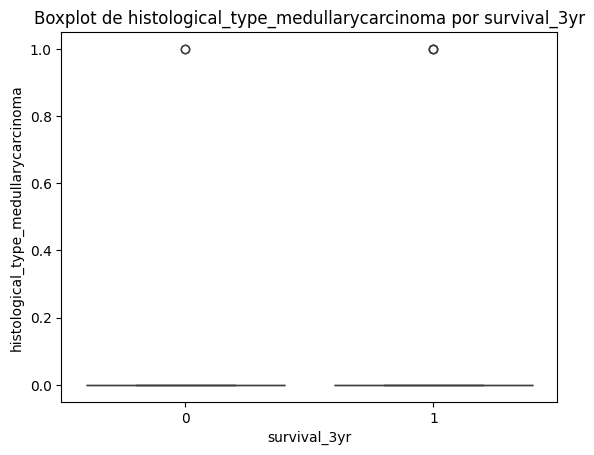

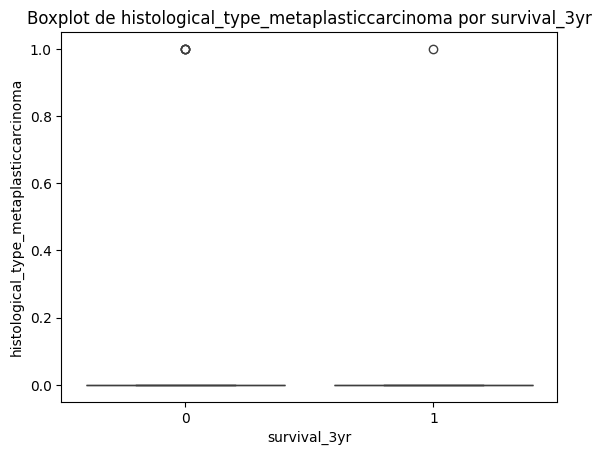

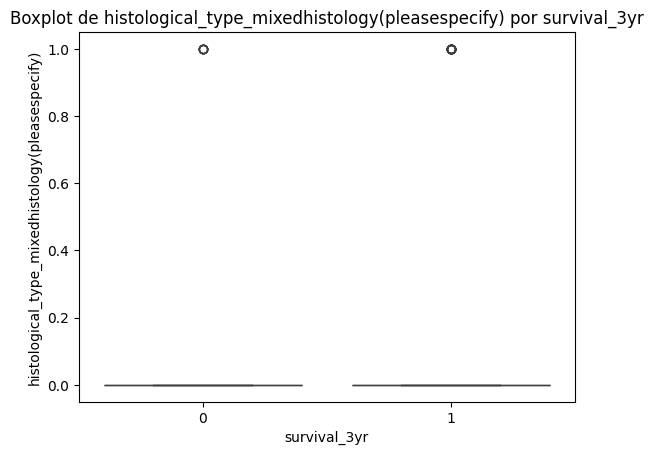

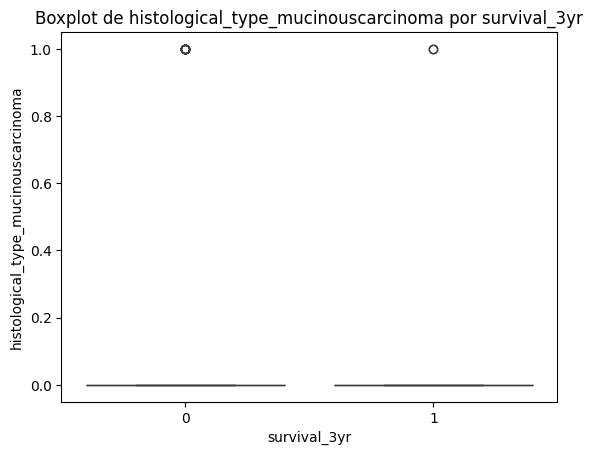

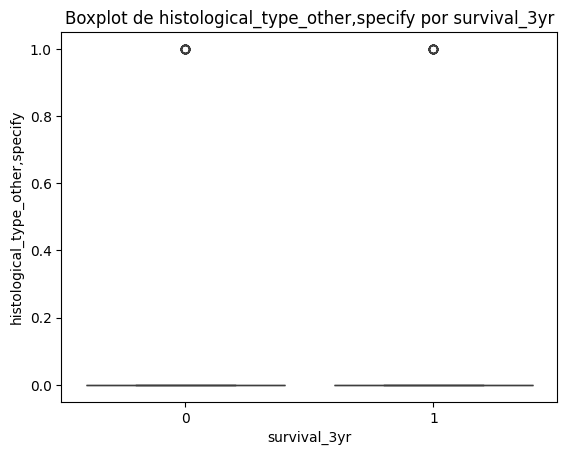

In [36]:
# Boxplots para variables numéricas vs target
num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
for col in num_cols:
    if col != 'survival_3yr':
        sns.boxplot(x='survival_3yr', y=col, data=merged_data)
        plt.title(f'Boxplot de {col} por survival_3yr')
        plt.show()

Hay un montón de variables fuera de rango, sin embargo son coherentes con la realidad. Esto significa que los modelos más adecuados para la predicción son aquellos que no sean sensibles a dichas anomalías.

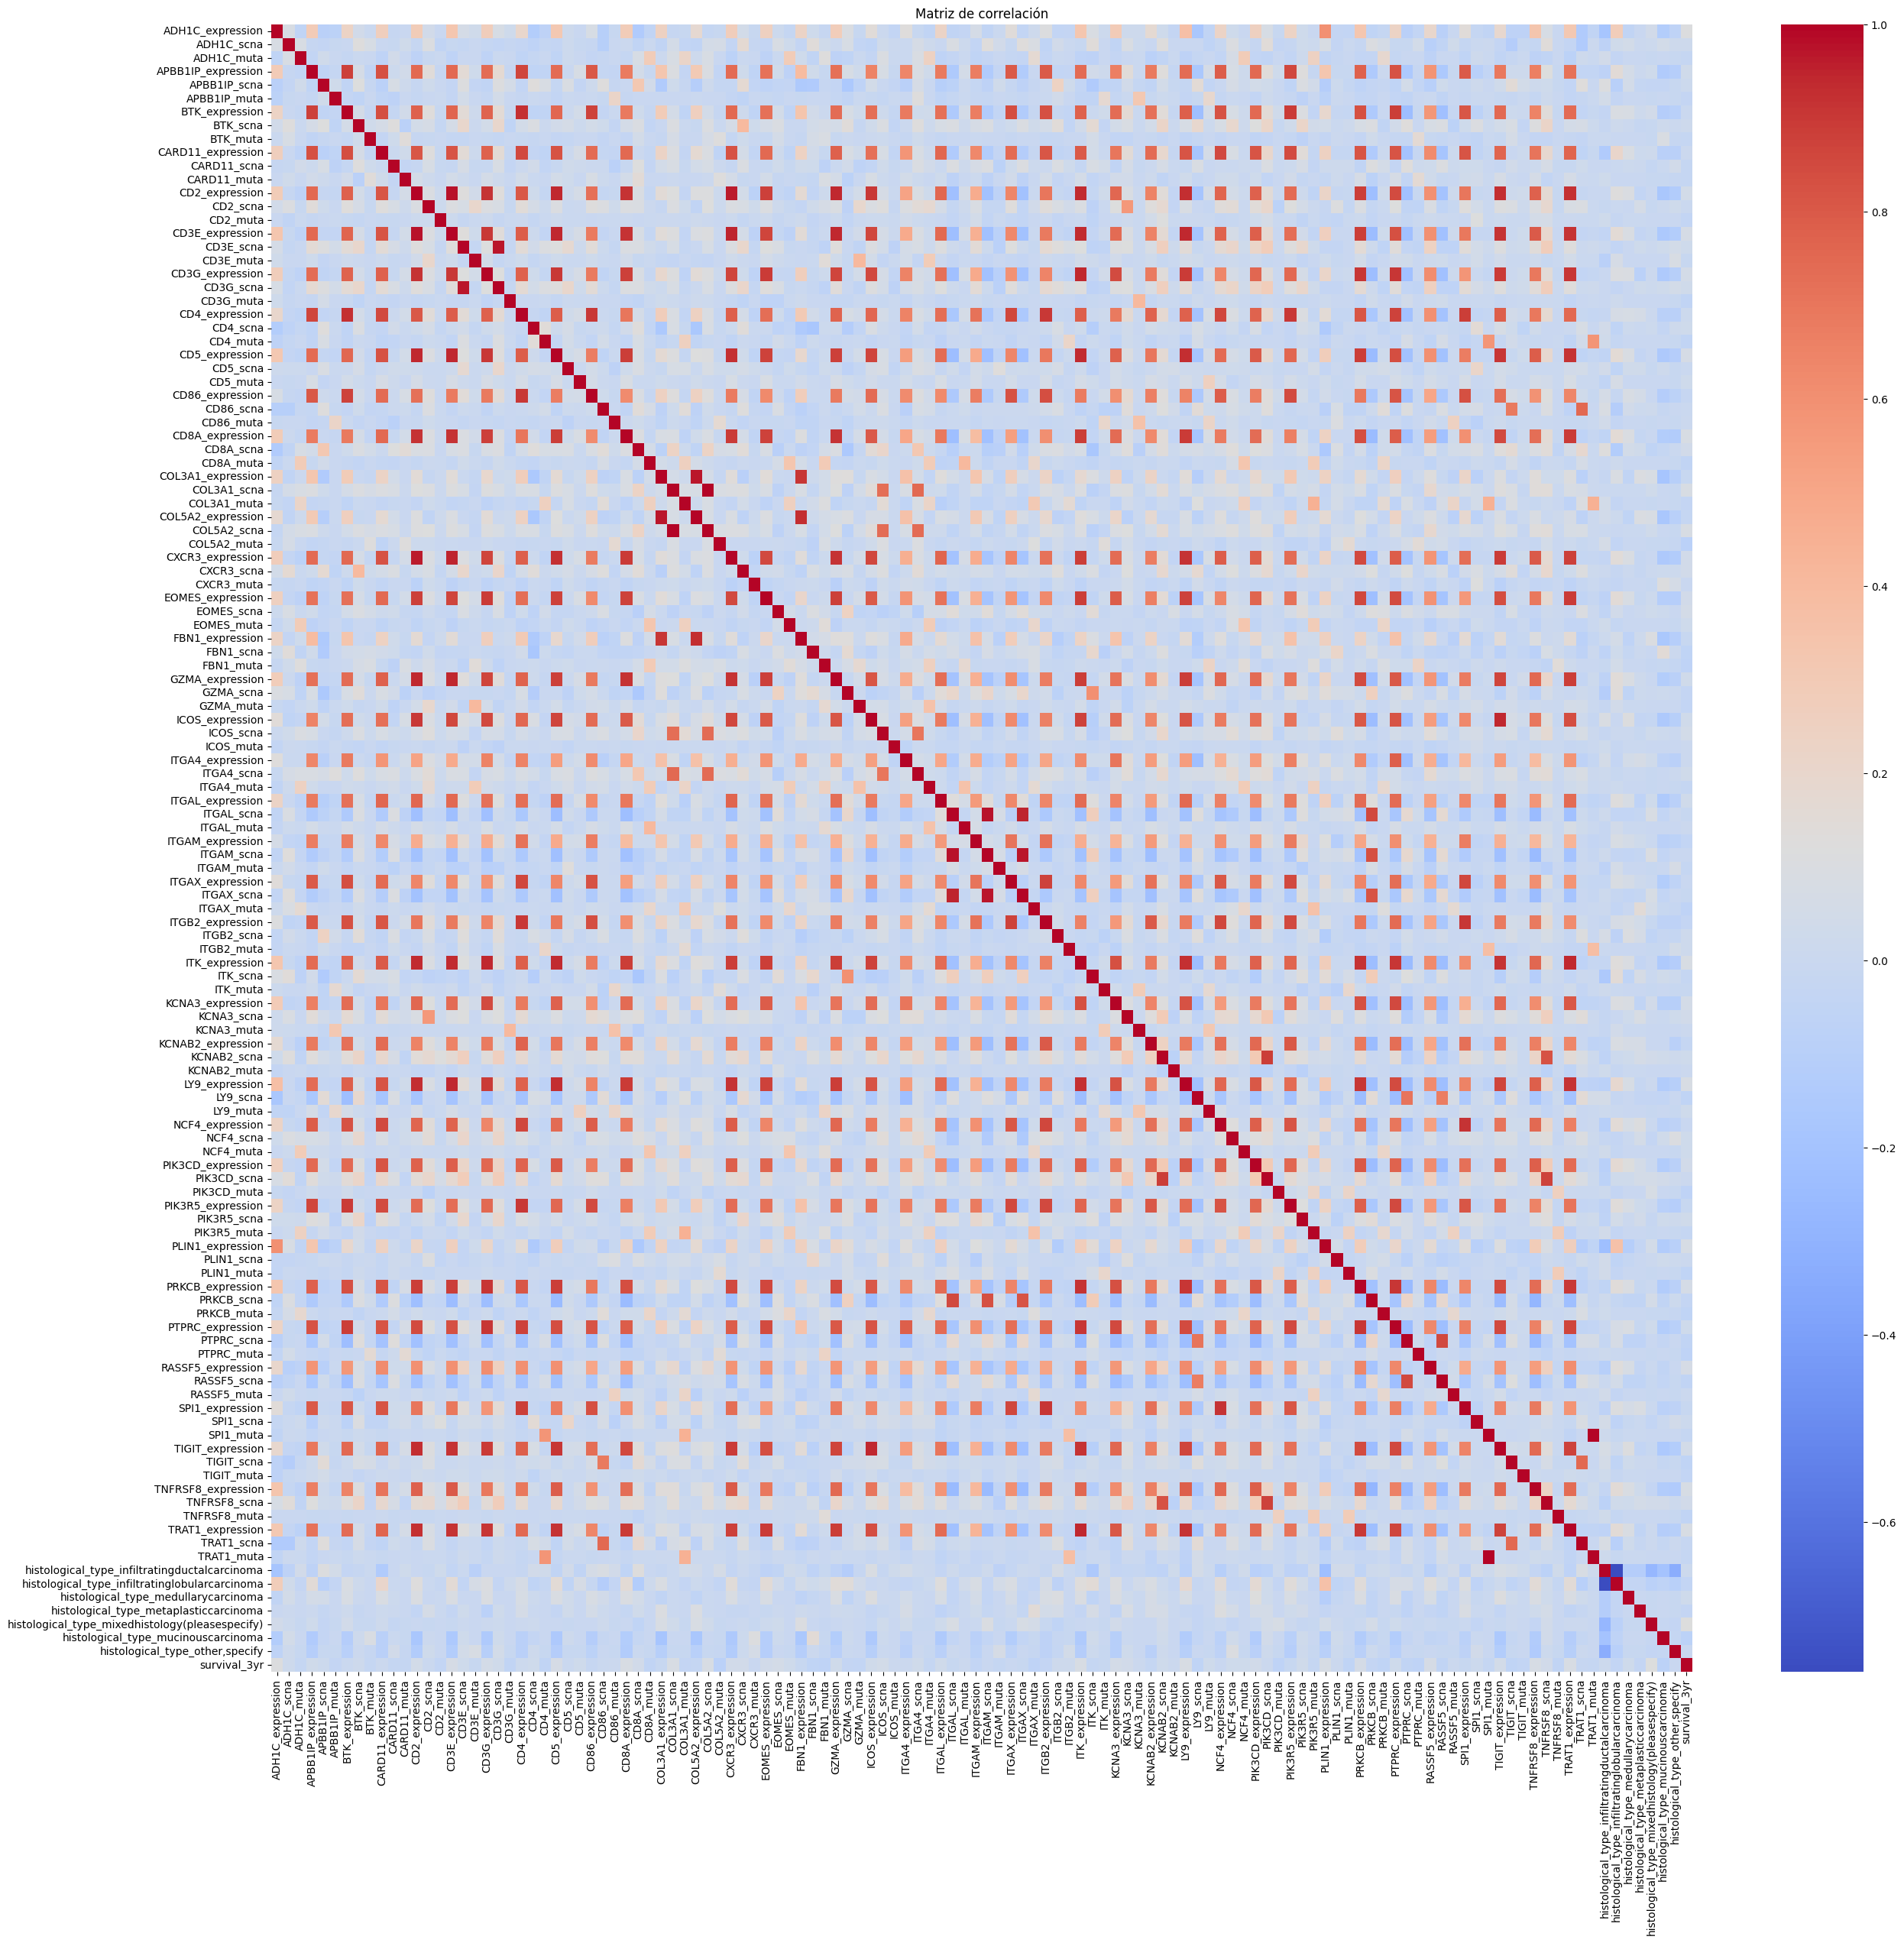

In [37]:
# Correlación de variables numéricas
plt.figure(figsize=(30, 28))
sns.heatmap(merged_data[num_cols].corr(), annot=False, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

Algunos genes mantienen cierta correlación entre sus valores, lo que puede significar alguna relación biológica en motivos comunes por ejemplo, asociados a funciones específicas.


Valor de conteos en histological_type_infiltratingductalcarcinoma:
histological_type_infiltratingductalcarcinoma
1.0    661
0.0    258
Name: count, dtype: int64


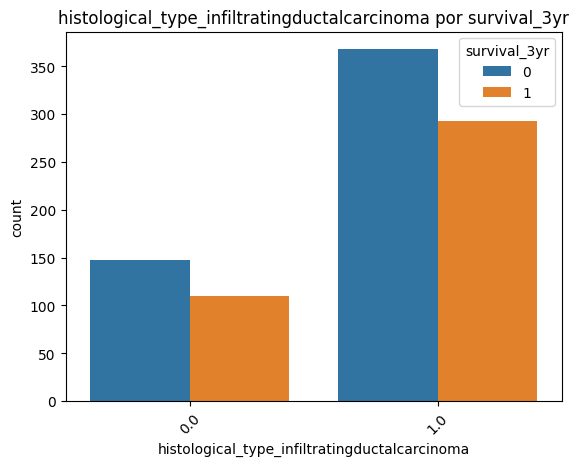


Valor de conteos en histological_type_infiltratinglobularcarcinoma:
histological_type_infiltratinglobularcarcinoma
0.0    750
1.0    169
Name: count, dtype: int64


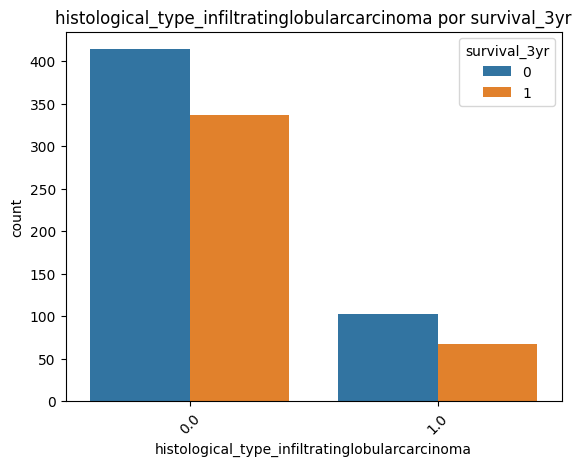


Valor de conteos en histological_type_medullarycarcinoma:
histological_type_medullarycarcinoma
0.0    914
1.0      5
Name: count, dtype: int64


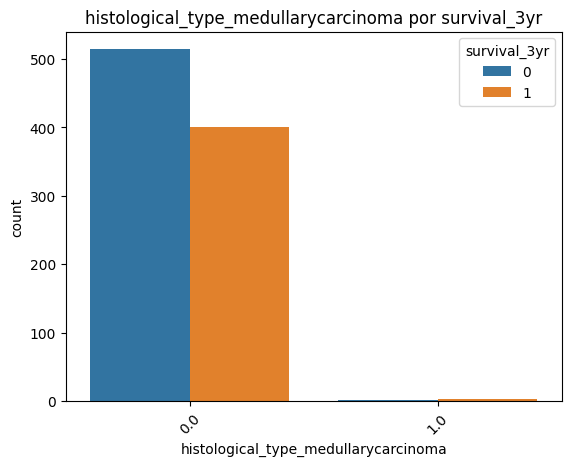


Valor de conteos en histological_type_metaplasticcarcinoma:
histological_type_metaplasticcarcinoma
0.0    914
1.0      5
Name: count, dtype: int64


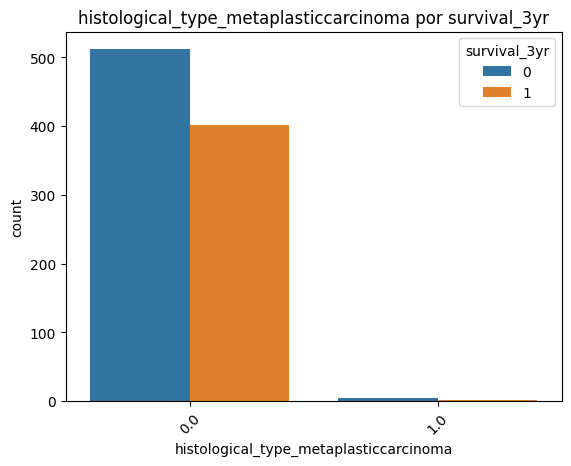


Valor de conteos en histological_type_mixedhistology(pleasespecify):
histological_type_mixedhistology(pleasespecify)
0.0    892
1.0     27
Name: count, dtype: int64


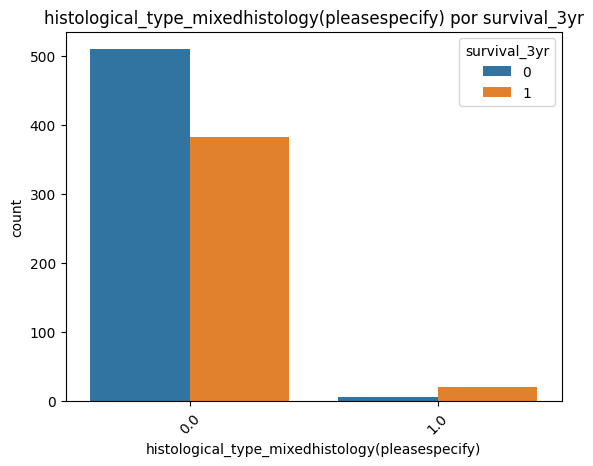


Valor de conteos en histological_type_mucinouscarcinoma:
histological_type_mucinouscarcinoma
0.0    905
1.0     14
Name: count, dtype: int64


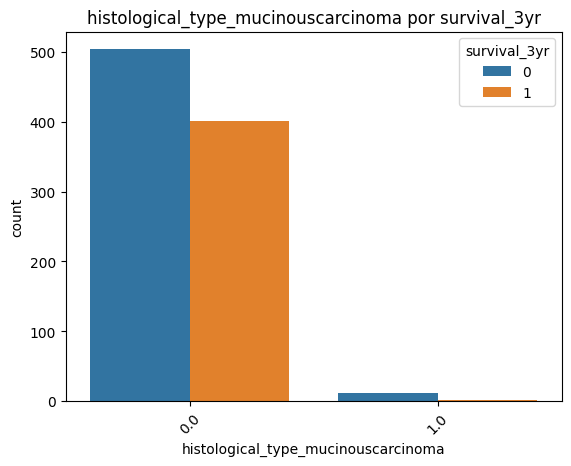


Valor de conteos en histological_type_other,specify:
histological_type_other,specify
0.0    881
1.0     38
Name: count, dtype: int64


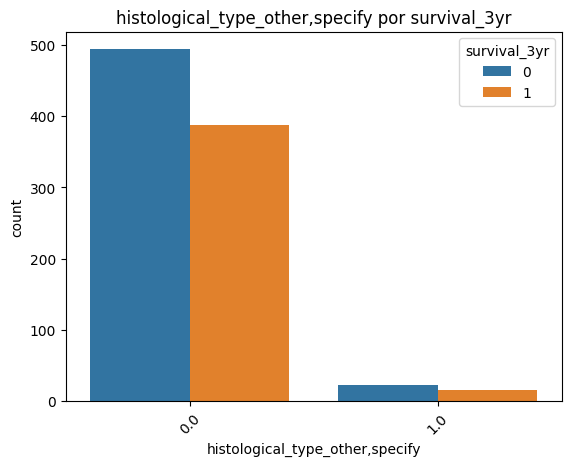

In [38]:
# Filtrar columnas que empiezan con 'histological_type'
hist_cols = [col for col in merged_data.columns if col.startswith('histological_type')]

for col in hist_cols:
    print(f"\nValor de conteos en {col}:")
    print(merged_data[col].value_counts())
    sns.countplot(x=col, data=merged_data, hue='survival_3yr')
    plt.title(f'{col} por survival_3yr')
    plt.xticks(rotation=45)
    plt.show()

In [39]:
#Correlación de Pearson para variables numéricas
num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
if 'survival_3yr' in num_cols:
    num_cols = num_cols.drop('survival_3yr')  # Evita autoco-correlación

correlations = merged_data[num_cols].corrwith(merged_data['survival_3yr']).abs().sort_values(ascending=False)
print("Correlaciones con survival_3yr:")
print(correlations)

Correlaciones con survival_3yr:
histological_type_mixedhistology(pleasespecify)    0.118951
ADH1C_expression                                   0.109520
ITK_expression                                     0.083758
COL5A2_muta                                        0.082816
COL5A2_scna                                        0.082800
                                                     ...   
CARD11_expression                                  0.004594
CD86_scna                                          0.003361
CD5_scna                                           0.002961
BTK_expression                                     0.001621
CD2_scna                                           0.000665
Length: 121, dtype: float64


Entre las 121 variables evaluadas, el tipo histológico mixto y la expresión/alteraciones de genes como ADH1C, ITK y COL5A2 son las que presentan mayor asociación positiva con la supervivencia a 3 años, aunque la fuerza de su correlación es débil. Los valores bajos sugieren que ningún factor individual explica gran parte de la variabilidad en supervivencia a 3 años, por lo tanto, puede ser necesario combinar variables en modelos multivariados para obtener predicciones robustas.

In [40]:
#Importancia según RandomForest (considerando todas las variables)
X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']

# Ya no aplicamos get_dummies porque las columnas histological_type ya están como one-hot
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)
print("Importancia según RandomForest:")
print(importancias)

Importancia según RandomForest:
ADH1C_expression     0.023477
KCNAB2_expression    0.017815
PLIN1_expression     0.016498
COL3A1_expression    0.016087
COL5A2_expression    0.015924
                       ...   
KCNAB2_muta          0.000000
SPI1_muta            0.000000
PRKCB_muta           0.000000
TRAT1_muta           0.000000
TIGIT_muta           0.000000
Length: 122, dtype: float64


Ciertos genes de expresión, como ADH1C, KCNAB2, PLIN1, COL3A1 y COL5A2, fueron identificados como los principales aportadores de información para la predicción de supervivencia (o desenlace similar) en el cohorte de cáncer.

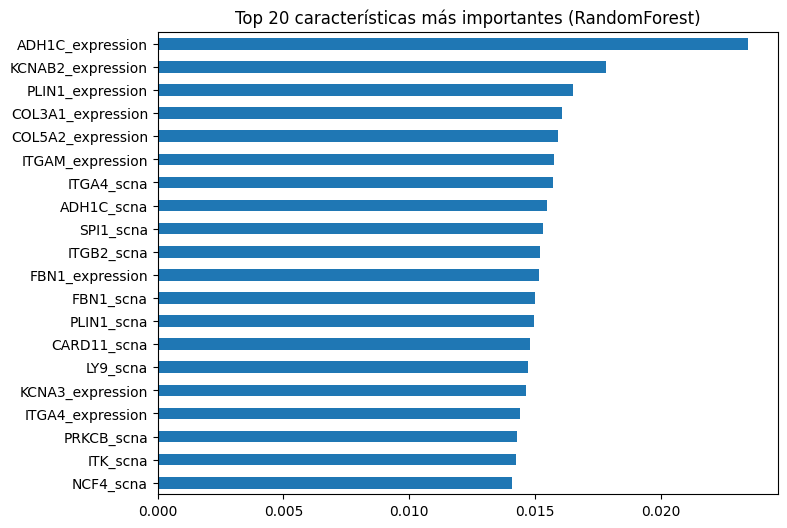

In [41]:
# Visualización
importancias.head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 características más importantes (RandomForest)')
plt.gca().invert_yaxis()
plt.show()

In [42]:
#Chi-cuadrado para variables categóricas (one-hot de histological_type)

if hist_cols:
    chi_scores = chi2(merged_data[hist_cols], y)
    chi2_df = pd.DataFrame({'Feature': hist_cols, 'Chi2 Score': chi_scores[0]})
    chi2_df = chi2_df.sort_values('Chi2 Score', ascending=False)
    print("Chi-cuadrado para variables histological_type:")
    print(chi2_df.head(10))
else:
    print("No se encontraron columnas que empiecen con 'histological_type' para análisis chi-cuadrado.")

Chi-cuadrado para variables histological_type:
                                           Feature  Chi2 Score
4  histological_type_mixedhistology(pleasespecify)   12.621162
5              histological_type_mucinouscarcinoma    4.970479
1   histological_type_infiltratinglobularcarcinoma    1.214834
3           histological_type_metaplasticcarcinoma    1.155304
2             histological_type_medullarycarcinoma    0.529521
0    histological_type_infiltratingductalcarcinoma    0.060511
6                  histological_type_other,specify    0.047089


El análisis de Chi-cuadrado reveló que los tumores de histología mixta presentan la diferencia más significativa respecto al desenlace clínico, mientras que otros subtipos, como el ductal infiltrante o el ‘otros’, no mostraron asociación estadísticamente relevante.

In [43]:
merged_data.to_csv('data/merged_data.csv', index=True)

print("Archivo CSV guardado en 'data/merged_data.csv'")

Archivo CSV guardado en 'data/merged_data.csv'
